In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *

from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
mouse = 26
day = 19

# good examples include 
#mice = [25, 25, 26, 27, 29, 28]
#days = [25, 24, 18, 26, 23, 25]

optimal travel lag is 9.55955955955956 cm based on kde of travel at max spatial information
using travel lag of 9.55955955955956 cm
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region 

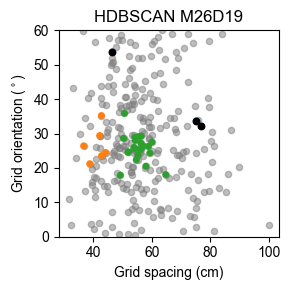

for module 0, there are 6 cells with average spacing 41.17343823635532
for module 1, there are 23 cells with average spacing 55.284238589219555
26 19
for module 0, there are 6 cells
for module 1, there are 23 cells
plotting vr rate maps using cluster_ids [24, 113, 114, 115, 123, 124, 126, 132, 133, 145, 149, 155, 156, 179, 183, 185, 195, 203, 221, 227, 298, 302, 340]


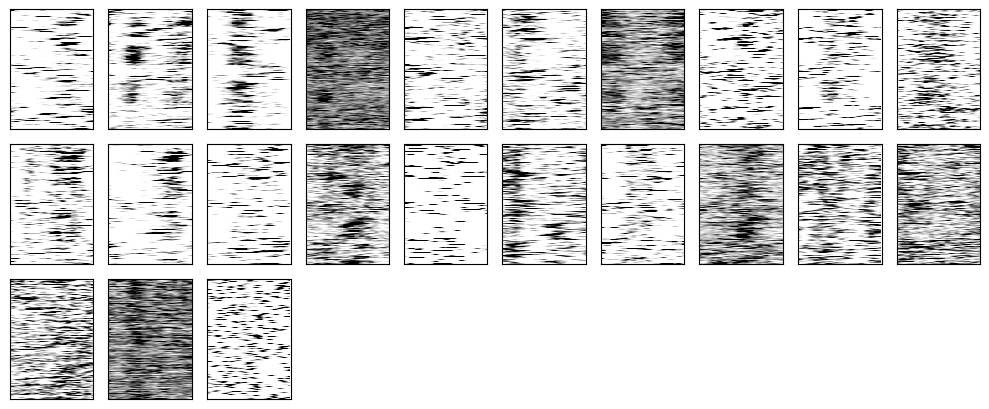

plotting vr rate maps using cluster_ids [163, 166, 201, 217, 224, 363]


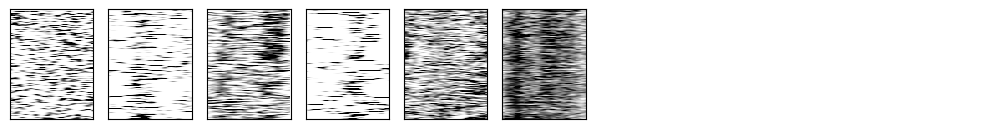

plotting vr rate maps using cluster_ids [14, 25, 34, 36, 37, 41, 42, 43, 48, 50, 53, 56, 58, 61, 65, 72, 93, 95, 100, 102, 103, 104, 112, 116, 120, 121, 122, 125, 128, 129, 130, 134, 135, 137, 138, 143, 144, 148, 151, 157, 169, 171, 172, 174, 176, 178, 180, 181, 186, 188, 189, 190, 192, 194, 196, 197, 198, 202, 205, 209, 210, 212, 213, 214, 215, 218, 219, 220, 223, 226, 239, 240, 241, 243, 245, 246, 247, 248, 249, 251, 252, 255, 257, 258, 259, 265, 266, 270, 271, 272, 273, 278, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 294, 296, 297, 299, 300, 301, 303, 304, 306, 309, 310, 311, 312, 313, 314, 315, 317, 318, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 333, 334, 335, 336, 337, 341, 342, 343, 344, 346, 347, 349, 350, 351, 352, 355, 356, 358, 359, 360, 362, 364, 365, 366, 369, 370, 372, 374, 376, 377, 378, 379, 380, 381, 382, 383, 384, 386, 387, 388, 389, 390, 394, 425, 426, 427, 428, 430, 431, 432, 433, 436, 437, 438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 449, 45

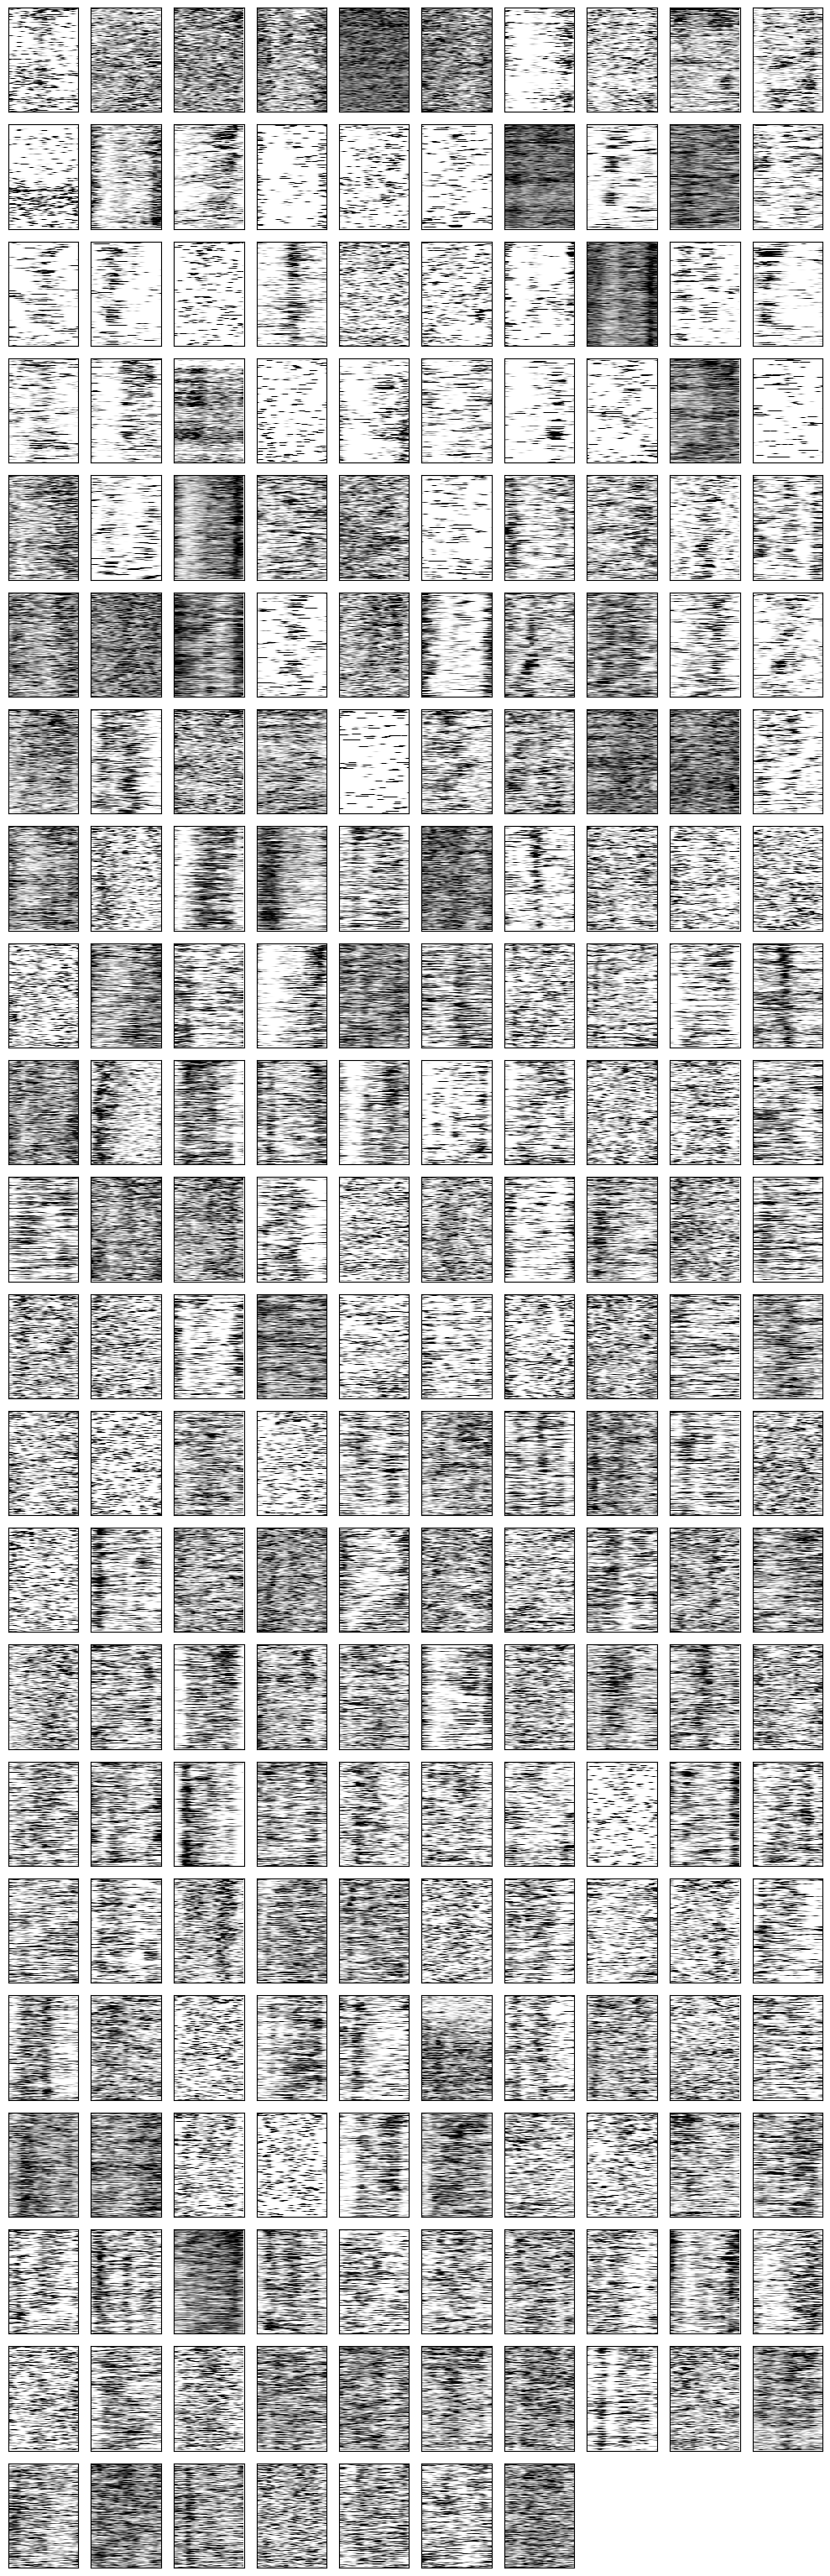

plotting vr rate maps using cluster_ids [18, 38, 110, 173, 242, 256, 263, 267, 268, 274, 275, 279, 291, 307, 320, 332, 338, 339, 348, 354, 361, 368, 371, 373, 391, 434, 460, 461, 462, 480, 485]


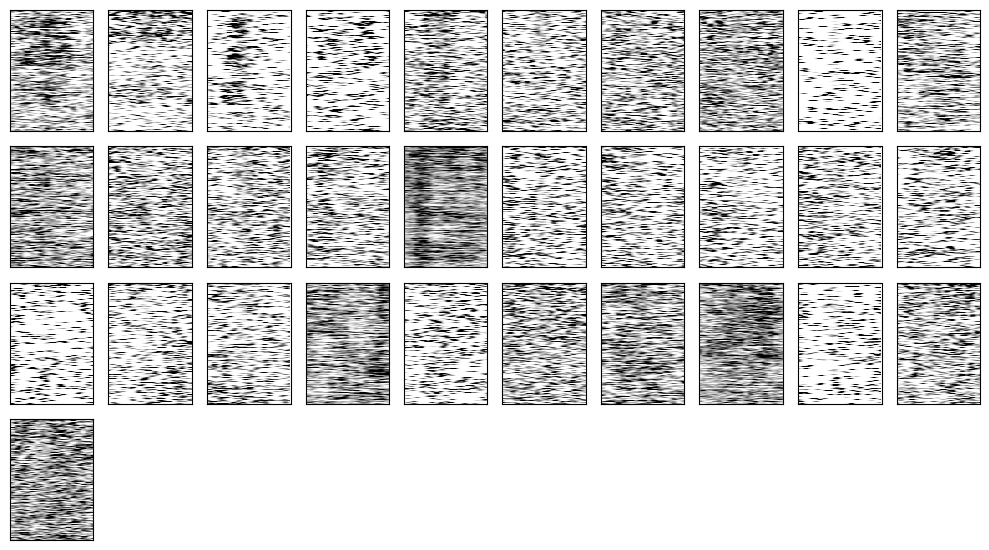

plotting vr rate maps using cluster_ids [24, 113, 114, 115, 123, 124, 126, 132, 133, 145, 149, 155, 156, 163, 166, 179, 183, 185, 195, 201, 203, 217, 221, 224, 227, 250, 269, 293, 298, 302, 340, 363]


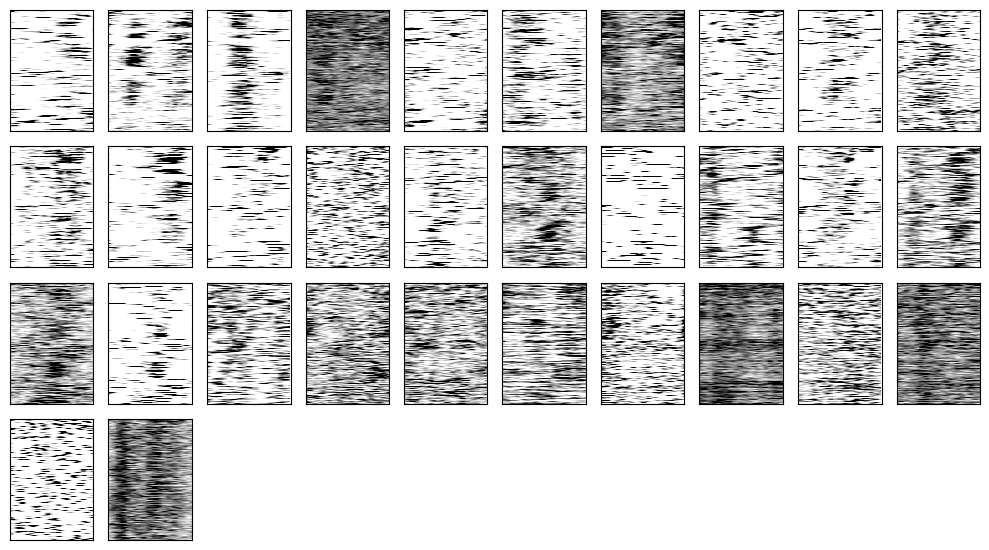

plotting vr rate maps using cluster_ids []


In [4]:
gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95) # subset
mec, para, pre, sub, vis, cere, other, all_by_anatomy = cell_classification_anatomy(mouse, day)

g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                figpath=fig_path, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False) # create grid modules using HDBSCAN    

plot_grid_modules_rate_maps(gcs, g_m_ids, g_m_cluster_ids, mouse, day, figpath=fig_path)

# we now have cluster ids classified into modules, non grid spatial cells and non spatial cells 
# as defined by activity in the open field
g_m_cluster_ids = sorted(g_m_cluster_ids, key=len, reverse=True) 
cluster_ids_by_group = []
cluster_ids_by_group.extend(g_m_cluster_ids) # grid cells by module [0,1,2...]
cluster_ids_by_group.append(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
cluster_ids_by_group.append(ns.cluster_id.values.tolist()) # non spatial cells [-3]
cluster_ids_by_group.append(gcs.cluster_id.values.tolist()) # all grid cells [-2]
cluster_ids_by_group.append(sc.cluster_id.values.tolist()) # speed cells [-1]

for m, cluster_ids in enumerate(cluster_ids_by_group):
    plot_vr_rate_maps(mouse, day, cluster_ids, label=f'{m}', figpath=fig_path)


In [ ]:
Mouse = f'M{mouse}'
data_paths = [f"/Users/harryclark/Documents/brainrender/probe_data/{Mouse}_probe_locations_{a}.mat" for a in [1,2,3,4]]
shank_offsets_SC = pd.read_csv('/Users/harryclark/Documents/brainrender/probe_data/shank_offsets.csv')
clusters_df = pd.read_csv(f'/Users/harryclark/Documents/brainrender/probe_data/extremum_channel_locations_kilosort4_0.csv')
clusters_df = clusters_df[clusters_df['mouse'] == mouse]
shank_offsets_SC = shank_offsets_SC[shank_offsets_SC['mouse'] == mouse]
clusters_df = reconstruct_shank_id(clusters_df, mouse)
probes_locs = [read_probe_mat(data_path) for data_path in data_paths]
adjusted_probes_locs_CCF = np.array([adjust_probe_locs(probe_locs) for probe_locs in probes_locs])
adjusted_probe_locs_SC, adjusted_probe_locs_CCF = correct_for_left_side(adjusted_probes_locs_CCF)
adjusted_probe_locs_SC, adjusted_probe_locs_CCF = adjust_to_shank_offsets(adjusted_probe_locs_SC, shank_offsets_SC)

ymin = -300; ymax = 3000
xmin = -200; xmax = 1000
xs = np.arange(xmin, xmax, 1)
ys = np.arange(ymin, ymax, 1)

annotations = np.zeros((len(ys), len(xs)), dtype=object)
for yi, y in enumerate(ys):
    for xi, x in enumerate(xs):
        coord_SC, coord_CCF  = brain_coord_from_xy(x, y, adjusted_probe_locs_SC, shank_id=0)
        # use the CCF coordinates, get an index and look up the annotation in the brainrender allen_brain_10um volume
        z_CCF, y_CCF, x_CCF = np.round(coord_CCF/10).astype(int)
        annotation_index = annotations_set[z_CCF,y_CCF,x_CCF]
        if len(structure_set[structure_set['id'] == annotation_index]) ==1:
            annotation = structure_set[structure_set['id'] == annotation_index]['acronym'].iloc[0]
        else:
            annotation ='root' # out of brain
        annotations[yi,xi] = annotation
annotation_colors = get_annotation_colors_2D(annotations)

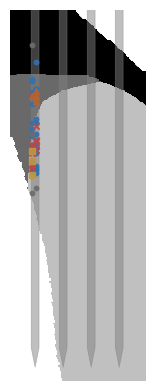

In [91]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
unique_colors = np.unique(annotation_colors)
for color in unique_colors:
    border_points = extract_border(annotation_colors, color, only_border=False)
    x_points = xs[border_points[:, 1]]
    y_points = ys[border_points[:, 0]]
    ax.scatter(x_points, y_points, color=color, s=1, label=color, rasterized=True)
plot_NP2_probe(ax, sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa', 
               probe_alpha=0.5, contacts_alpha=0.0, probe_color='grey', probe_edgecolor='black')
# plot cell locations 
ax.scatter(ngs.probe_x.values, ngs.probe_y.values, marker='o', color="#3171ae", alpha=0.9, s=10)
ax.scatter(ns.probe_x.values, ns.probe_y.values, marker='o', color="#6c6c6c", alpha=0.9, s=10)

markers = ['x','^', 's']
colors=["#c04744", "#B6632F", "#c09744"]
for i, cluster_ids in enumerate(g_m_cluster_ids):
    gc_m = gcs[np.isin(gcs.cluster_id, cluster_ids)]
    ax.scatter(gc_m.probe_x.values, gc_m.probe_y.values, marker=markers[i], color=colors[i], alpha=0.9, s=20)
plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_probe_brainrender.pdf', bbox_inches='tight', dpi=500) # use tight layout to avoid cutting off labels
plt.show()

In [38]:
tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse,day, apply_zscore=False, apply_guassian_filter=False)

last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

# time binned variables for later
ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
speed_in_time = np.array(beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep))
dt_in_time = np.array(beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl))
pos_in_time = dt_in_time%tl
trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

if np.any(np.isnan(pos_in_time)):
    series = pd.Series(dt_in_time)
    filled_series = series.ffill().bfill()
    dt_in_time = np.array(filled_series)
    pos_in_time = dt_in_time%tl
    trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

if np.any(np.isnan(speed_in_time)):
    series = pd.Series(speed_in_time)
    filled_series = series.ffill().bfill()
    speed_in_time = np.array(speed_in_time)

# compute the spectrogram and labels from the most adunant grid module
peak_indices = [12, 28, 44, 60, 76]
cluster_ids = g_m_cluster_ids[0]
tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
results = spectral_analysis(tcs_to_use, tl, bs=bs)
spectrograms = results[3] 
fvalid = results[5]
S = spectrograms.mean(0)
max_peaks = np.argmax(S, axis=0)
labels = np.isin(max_peaks, peak_indices).astype(int)

# compute trial labels for task anchoring to use in the xgboost model mask
tc = tcs[172] # example grid cell
tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
tc = tc[:last_ephys_bin] # only want bins with ephys data in it
trial_labels = get_kmeans_spatial_labels(tc, labels, bs=bs, tl=tl) # reuse kmeans function to get the labels based on the task anchoring

Identified 1 candidate modules


plot a grid cell

In [39]:
xgb_history = MLencoding(tunemodel = 'xgboost',
                         cov_history = True, spike_history=False, # We can choose!
                         window = time_bs, #this dataset has 100ms time bins
                         n_filters = 5,
                         max_time = 1000)

In [40]:
test_grid_cell_id = 172  # the grid cell we will use to test the model
predictor_co_modular_grid_cell_id = 187  # a co modular grid cell
predictor_non_co_modular_grid_cell_id = 236 # a non co modular grid cell
predictor_non_co_modular_grid_cell_id2 = 128 # another non co modular grid cell
predictor_ngs_cell_id = 174  # a non grid spatial cell

print(f'Grid cell id: {test_grid_cell_id}')
print(f'Co-modular grid cell id: {predictor_co_modular_grid_cell_id}')
print(f'Non co-modular grid cell id: {predictor_non_co_modular_grid_cell_id}')
print(f'Non co-modular grid cell id2: {predictor_non_co_modular_grid_cell_id2}')
print(f'Non grid spatial cell id: {predictor_ngs_cell_id}') 

Grid cell id: 172
Co-modular grid cell id: 187
Non co-modular grid cell id: 236
Non co-modular grid cell id2: 128
Non grid spatial cell id: 174


plot a reference grid cell
n trials: 225


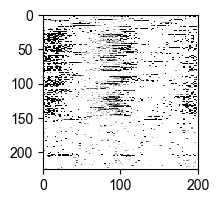

plot a co modular grid cell
n trials: 225


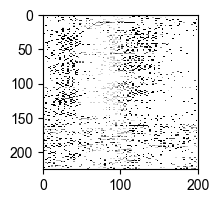

plot a non co modular grid cell
n trials: 225


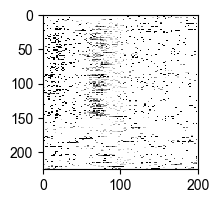

plot another non co modular grid cell
n trials: 225


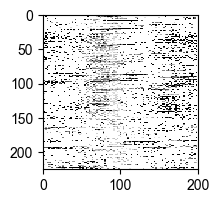

plot a ngs cell
n trials: 225


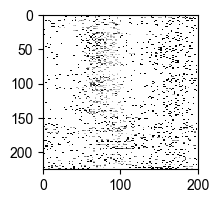

In [41]:
print('plot a reference grid cell')
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(2, 2), squeeze=False)
plot_firing_rate_map(ax[0,0], zscore(tcs[test_grid_cell_id]), bs=bs, tl=tl, p=95)
plt.show()
print('plot a co modular grid cell')
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(2, 2), squeeze=False)
plot_firing_rate_map(ax[0,0], zscore(tcs[predictor_co_modular_grid_cell_id]), bs=bs, tl=tl, p=95)
plt.show()

print('plot a non co modular grid cell')
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(2, 2), squeeze=False)
plot_firing_rate_map(ax[0,0], zscore(tcs[predictor_non_co_modular_grid_cell_id]), bs=bs, tl=tl, p=95)
plt.show()

print('plot another non co modular grid cell')
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(2, 2), squeeze=False)
plot_firing_rate_map(ax[0,0], zscore(tcs[predictor_non_co_modular_grid_cell_id2]), bs=bs, tl=tl, p=95)
plt.show()

print('plot a ngs cell')
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(2, 2), squeeze=False)
plot_firing_rate_map(ax[0,0], zscore(tcs[predictor_ngs_cell_id]), bs=bs, tl=tl, p=95)
plt.show()

In [42]:
module_1_ids = g_m_cluster_ids[0].copy()
module_1_ids.remove(test_grid_cell_id)
module_2_ids = g_m_cluster_ids[1].copy()
module_3_ids = g_m_cluster_ids[2].copy()
ngs_ids = ngs.cluster_id.values.tolist()

cov_tcs_time_module_1 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_1_ids if cluster_id in tcs_time}
cov_tcs_time_module_2 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_2_ids if cluster_id in tcs_time} 
cov_tcs_time_module_3 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_3_ids if cluster_id in tcs_time}
cov_tcs_time_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in ngs_ids if cluster_id in tcs_time}

In [61]:
y = np.array(tcs_time[test_grid_cell_id]) # target variable is the test grid cell
y_smoothed = gaussian_filter_nan(y, sigma=3) # smooth the target variable
X  = np.stack([pos_in_time]).T # pos in time

Xg1 = np.stack([np.array(tcs_time[predictor_co_modular_grid_cell_id])]).T # co modular grid cell
Xg2 = np.stack([np.array(tcs_time[predictor_non_co_modular_grid_cell_id])]).T # non co modular grid cell
Xg3 = np.stack([np.array(tcs_time[predictor_non_co_modular_grid_cell_id2])]).T # another non co modular grid cell
Xngs4 = np.stack([np.array(tcs_time[predictor_ngs_cell_id])]).T # ngs cell 2

Xpos_g1 = np.stack([pos_in_time, np.array(tcs_time[predictor_co_modular_grid_cell_id])]).T # co modular grid cell + pos in time
Xpos_g2 = np.stack([pos_in_time, np.array(tcs_time[predictor_non_co_modular_grid_cell_id])]).T # non co modular grid cell + pos in time
Xpos_g3 = np.stack([pos_in_time, np.array(tcs_time[predictor_non_co_modular_grid_cell_id2])]).T # another non co modular grid cell + pos in time
Xpos_ngs4 = np.stack([pos_in_time, np.array(tcs_time[predictor_ngs_cell_id])]).T # ngs cell 2 + pos in time

Xm1 = np.column_stack((np.vstack(list(cov_tcs_time_module_1.values())).T)).T # module 1 grid cells
Xm2 = np.column_stack((np.vstack(list(cov_tcs_time_module_2.values())).T)).T # module 2 grid cells
Xm3 = np.column_stack((np.vstack(list(cov_tcs_time_module_3.values())).T)).T # module 3 grid cells
Xngs = np.column_stack((np.vstack(list(cov_tcs_time_ngs.values())).T)).T # non grid cells

Xpos_m1 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_module_1.values())).T)) # module 1 grid cells + pos in time
Xpos_m2 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_module_2.values())).T)) # module 2 grid cells + pos in time
Xpos_m3 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_module_3.values())).T)) # module 3 grid cells + pos in time
Xpos_ngs = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_ngs.values())).T)) # non grid cells + pos in time

# train model on TA trials and test on TA trials
train_trials = beh['trials'][:len(trial_labels)]
test_trials = beh['trials'][:len(trial_labels)]

train_label = 1
test_label = 0

train_trials = train_trials[trial_labels == train_label]['number'].values
test_trials = test_trials[trial_labels == test_label]['number'].values

train_mask = np.isin(trial_number_in_time, train_trials)
test_mask = np.isin(trial_number_in_time, test_trials)

# fit the model on the training trials
Y_hat_p_trainTA_testTI, pR2_condition_cv_trainTA_testTI = xgb_history.fit_predefined_sets(X, y, train_mask, test_mask)
Y_hat_g1_trainTA_testTI, pR2_condition_cv_g1_trainTA_testTI = xgb_history.fit_predefined_sets(Xg1, y, train_mask, test_mask)
Y_hat_g2_trainTA_testTI, pR2_condition_cv_g2_trainTA_testTI = xgb_history.fit_predefined_sets(Xg2, y, train_mask, test_mask)
Y_hat_g3_trainTA_testTI, pR2_condition_cv_g3_trainTA_testTI = xgb_history.fit_predefined_sets(Xg3, y, train_mask, test_mask)
Y_hat_ngs4_trainTA_testTI, pR2_condition_cv_ngs4_trainTA_testTI = xgb_history.fit_predefined_sets(Xngs4, y, train_mask, test_mask)
Y_hat_m1_trainTA_testTI, pR2_condition_cv_m1_trainTA_testTI = xgb_history.fit_predefined_sets(Xm1, y, train_mask, test_mask)
Y_hat_m2_trainTA_testTI, pR2_condition_cv_m2_trainTA_testTI = xgb_history.fit_predefined_sets(Xm2, y, train_mask, test_mask)
Y_hat_m3_trainTA_testTI, pR2_condition_cv_m3_trainTA_testTI = xgb_history.fit_predefined_sets(Xm3, y, train_mask, test_mask)
Y_hat_ngs_trainTA_testTI, pR2_condition_cv_ngs_trainTA_testTI = xgb_history.fit_predefined_sets(Xngs, y, train_mask, test_mask)

Y_hat_pos_g1_trainTA_testTI, pR2_condition_cv_pos_g1_trainTA_testTI = xgb_history.fit_predefined_sets(Xpos_g1, y, train_mask, test_mask)
Y_hat_pos_g2_trainTA_testTI, pR2_condition_cv_pos_g2_trainTA_testTI = xgb_history.fit_predefined_sets(Xpos_g2, y, train_mask, test_mask)
Y_hat_pos_g3_trainTA_testTI, pR2_condition_cv_pos_g3_trainTA_testTI = xgb_history.fit_predefined_sets(Xpos_g3, y, train_mask, test_mask)
Y_hat_pos_ngs4_trainTA_testTI, pR2_condition_cv_pos_ngs4_trainTA_testTI = xgb_history.fit_predefined_sets(Xpos_ngs4, y, train_mask, test_mask)
Y_hat_pos_m1_trainTA_testTI, pR2_condition_cv_pos_m1_trainTA_testTI = xgb_history.fit_predefined_sets(Xpos_m1, y, train_mask, test_mask)
Y_hat_pos_m2_trainTA_testTI, pR2_condition_cv_pos_m2_trainTA_testTI = xgb_history.fit_predefined_sets(Xpos_m2, y, train_mask, test_mask)
Y_hat_pos_m3_trainTA_testTI, pR2_condition_cv_pos_m3_trainTA_testTI = xgb_history.fit_predefined_sets(Xpos_m3, y, train_mask, test_mask)
Y_hat_pos_ngs_trainTA_testTI, pR2_condition_cv_pos_ngs_trainTA_testTI = xgb_history.fit_predefined_sets(Xpos_ngs, y, train_mask, test_mask)

Y_hat_p_trainTA_testTI_ = np.zeros(len(y)); Y_hat_p_trainTA_testTI_[test_mask] = Y_hat_p_trainTA_testTI
Y_hat_g1_trainTA_testTI_ = np.zeros(len(y)); Y_hat_g1_trainTA_testTI_[test_mask] = Y_hat_g1_trainTA_testTI
Y_hat_g2_trainTA_testTI_ = np.zeros(len(y)); Y_hat_g2_trainTA_testTI_[test_mask] = Y_hat_g2_trainTA_testTI
Y_hat_g3_trainTA_testTI_ = np.zeros(len(y)); Y_hat_g3_trainTA_testTI_[test_mask] = Y_hat_g3_trainTA_testTI
Y_hat_ngs4_trainTA_testTI_ = np.zeros(len(y)); Y_hat_ngs4_trainTA_testTI_[test_mask] = Y_hat_ngs4_trainTA_testTI
Y_hat_m1_trainTA_testTI_ = np.zeros(len(y)); Y_hat_m1_trainTA_testTI_[test_mask] = Y_hat_m1_trainTA_testTI
Y_hat_m2_trainTA_testTI_ = np.zeros(len(y)); Y_hat_m2_trainTA_testTI_[test_mask] = Y_hat_m2_trainTA_testTI
Y_hat_m3_trainTA_testTI_ = np.zeros(len(y)); Y_hat_m3_trainTA_testTI_[test_mask] = Y_hat_m3_trainTA_testTI
Y_hat_ngs_trainTA_testTI_ = np.zeros(len(y)); Y_hat_ngs_trainTA_testTI_[test_mask] = Y_hat_ngs_trainTA_testTI

Y_hat_pos_g1_trainTA_testTI_ = np.zeros(len(y)); Y_hat_pos_g1_trainTA_testTI_[test_mask] = Y_hat_pos_g1_trainTA_testTI
Y_hat_pos_g2_trainTA_testTI_ = np.zeros(len(y)); Y_hat_pos_g2_trainTA_testTI_[test_mask] = Y_hat_pos_g2_trainTA_testTI
Y_hat_pos_g3_trainTA_testTI_ = np.zeros(len(y)); Y_hat_pos_g3_trainTA_testTI_[test_mask] = Y_hat_pos_g3_trainTA_testTI
Y_hat_pos_ngs4_trainTA_testTI_ = np.zeros(len(y)); Y_hat_pos_ngs4_trainTA_testTI_[test_mask] = Y_hat_pos_ngs4_trainTA_testTI
Y_hat_pos_m1_trainTA_testTI_ = np.zeros(len(y)); Y_hat_pos_m1_trainTA_testTI_[test_mask] = Y_hat_pos_m1_trainTA_testTI
Y_hat_pos_m2_trainTA_testTI_ = np.zeros(len(y)); Y_hat_pos_m2_trainTA_testTI_[test_mask] = Y_hat_pos_m2_trainTA_testTI
Y_hat_pos_m3_trainTA_testTI_ = np.zeros(len(y)); Y_hat_pos_m3_trainTA_testTI_[test_mask] = Y_hat_pos_m3_trainTA_testTI
Y_hat_pos_ngs_trainTA_testTI_ = np.zeros(len(y)); Y_hat_pos_ngs_trainTA_testTI_[test_mask] = Y_hat_pos_ngs_trainTA_testTI


# train model on TA trials and test on TA trials
train_trials = beh['trials'][:len(trial_labels)]
test_trials = beh['trials'][:len(trial_labels)]

train_label = 0
test_label = 1

train_trials = train_trials[trial_labels == train_label]['number'].values
test_trials = test_trials[trial_labels == test_label]['number'].values

train_mask = np.isin(trial_number_in_time, train_trials)
test_mask = np.isin(trial_number_in_time, test_trials)

# fit the model on the training trials
Y_hat_p_trainTI_testTA, pR2_condition_cv_trainTI_testTA = xgb_history.fit_predefined_sets(X, y, train_mask, test_mask)
Y_hat_g1_trainTI_testTA, pR2_condition_cv_g1_trainTI_testTA = xgb_history.fit_predefined_sets(Xg1, y, train_mask, test_mask)
Y_hat_g2_trainTI_testTA, pR2_condition_cv_g2_trainTI_testTA = xgb_history.fit_predefined_sets(Xg2, y, train_mask, test_mask)
Y_hat_g3_trainTI_testTA, pR2_condition_cv_g3_trainTI_testTA = xgb_history.fit_predefined_sets(Xg3, y, train_mask, test_mask)
Y_hat_ngs4_trainTI_testTA, pR2_condition_cv_ngs4_trainTI_testTA = xgb_history.fit_predefined_sets(Xngs4, y, train_mask, test_mask)
Y_hat_m1_trainTI_testTA, pR2_condition_cv_m1_trainTI_testTA = xgb_history.fit_predefined_sets(Xm1, y, train_mask, test_mask)
Y_hat_m2_trainTI_testTA, pR2_condition_cv_m2_trainTI_testTA = xgb_history.fit_predefined_sets(Xm2, y, train_mask, test_mask)
Y_hat_m3_trainTI_testTA, pR2_condition_cv_m3_trainTI_testTA = xgb_history.fit_predefined_sets(Xm3, y, train_mask, test_mask)
Y_hat_ngs_trainTI_testTA, pR2_condition_cv_ngs_trainTI_testTA = xgb_history.fit_predefined_sets(Xngs, y, train_mask, test_mask)

Y_hat_pos_g1_trainTI_testTA, pR2_condition_cv_pos_g1_trainTI_testTA = xgb_history.fit_predefined_sets(Xpos_g1, y, train_mask, test_mask)
Y_hat_pos_g2_trainTI_testTA, pR2_condition_cv_pos_g2_trainTI_testTA = xgb_history.fit_predefined_sets(Xpos_g2, y, train_mask, test_mask)
Y_hat_pos_g3_trainTI_testTA, pR2_condition_cv_pos_g3_trainTI_testTA = xgb_history.fit_predefined_sets(Xpos_g3, y, train_mask, test_mask)
Y_hat_pos_ngs4_trainTI_testTA, pR2_condition_cv_pos_ngs4_trainTI_testTA = xgb_history.fit_predefined_sets(Xpos_ngs4, y, train_mask, test_mask)
Y_hat_pos_m1_trainTI_testTA, pR2_condition_cv_pos_m1_trainTI_testTA = xgb_history.fit_predefined_sets(Xpos_m1, y, train_mask, test_mask)
Y_hat_pos_m2_trainTI_testTA, pR2_condition_cv_pos_m2_trainTI_testTA = xgb_history.fit_predefined_sets(Xpos_m2, y, train_mask, test_mask)
Y_hat_pos_m3_trainTI_testTA, pR2_condition_cv_pos_m3_trainTI_testTA = xgb_history.fit_predefined_sets(Xpos_m3, y, train_mask, test_mask)
Y_hat_pos_ngs_trainTI_testTA, pR2_condition_cv_pos_ngs_trainTI_testTA = xgb_history.fit_predefined_sets(Xpos_ngs, y, train_mask, test_mask)

Y_hat_p_trainTI_testTA_ = np.zeros(len(y)); Y_hat_p_trainTI_testTA_[test_mask] = Y_hat_p_trainTI_testTA
Y_hat_g1_trainTI_testTA_ = np.zeros(len(y)); Y_hat_g1_trainTI_testTA_[test_mask] = Y_hat_g1_trainTI_testTA
Y_hat_g2_trainTI_testTA_ = np.zeros(len(y)); Y_hat_g2_trainTI_testTA_[test_mask] = Y_hat_g2_trainTI_testTA
Y_hat_g3_trainTI_testTA_ = np.zeros(len(y)); Y_hat_g3_trainTI_testTA_[test_mask] = Y_hat_g3_trainTI_testTA
Y_hat_ngs4_trainTI_testTA_ = np.zeros(len(y)); Y_hat_ngs4_trainTI_testTA_[test_mask] = Y_hat_ngs4_trainTI_testTA
Y_hat_m1_trainTI_testTA_ = np.zeros(len(y)); Y_hat_m1_trainTI_testTA_[test_mask] = Y_hat_m1_trainTI_testTA
Y_hat_m2_trainTI_testTA_ = np.zeros(len(y)); Y_hat_m2_trainTI_testTA_[test_mask] = Y_hat_m2_trainTI_testTA
Y_hat_m3_trainTI_testTA_ = np.zeros(len(y)); Y_hat_m3_trainTI_testTA_[test_mask] = Y_hat_m3_trainTI_testTA
Y_hat_ngs_trainTI_testTA_ = np.zeros(len(y)); Y_hat_ngs_trainTI_testTA_[test_mask] = Y_hat_ngs_trainTI_testTA

Y_hat_pos_g1_trainTI_testTA_ = np.zeros(len(y)); Y_hat_pos_g1_trainTI_testTA_[test_mask] = Y_hat_pos_g1_trainTI_testTA
Y_hat_pos_g2_trainTI_testTA_ = np.zeros(len(y)); Y_hat_pos_g2_trainTI_testTA_[test_mask] = Y_hat_pos_g2_trainTI_testTA
Y_hat_pos_g3_trainTI_testTA_ = np.zeros(len(y)); Y_hat_pos_g3_trainTI_testTA_[test_mask] = Y_hat_pos_g3_trainTI_testTA
Y_hat_pos_ngs4_trainTI_testTA_ = np.zeros(len(y)); Y_hat_pos_ngs4_trainTI_testTA_[test_mask] = Y_hat_pos_ngs4_trainTI_testTA
Y_hat_pos_m1_trainTI_testTA_ = np.zeros(len(y)); Y_hat_pos_m1_trainTI_testTA_[test_mask] = Y_hat_pos_m1_trainTI_testTA
Y_hat_pos_m2_trainTI_testTA_ = np.zeros(len(y)); Y_hat_pos_m2_trainTI_testTA_[test_mask] = Y_hat_pos_m2_trainTI_testTA
Y_hat_pos_m3_trainTI_testTA_ = np.zeros(len(y)); Y_hat_pos_m3_trainTI_testTA_[test_mask] = Y_hat_pos_m3_trainTI_testTA
Y_hat_pos_ngs_trainTI_testTA_ = np.zeros(len(y)); Y_hat_pos_ngs_trainTI_testTA_[test_mask] = Y_hat_pos_ngs_trainTI_testTA


pR2:  -0.0017250117562035427
pR2:  0.027718761019056903
pR2:  -0.03341702184025941
pR2:  0.009858061649182237
pR2:  0.003072204926604094
pR2:  0.3860888378667121
pR2:  0.04432620176328428
pR2:  0.08194750607907553
pR2:  0.25275761741172575
pR2:  0.05826961565549771
pR2:  0.026401338440342204
pR2:  0.04168207806017987
pR2:  0.035669330277196654
pR2:  0.36659924458081916
pR2:  0.08867426541194412
pR2:  0.11945564637259354
pR2:  0.26512722082247486
pR2:  0.04959964027039143
pR2:  0.01010273005508866
pR2:  -0.023121960656632856
pR2:  -0.024660140916684226
pR2:  -0.013219759995979574
pR2:  0.284882906419349
pR2:  -0.02025039262176409
pR2:  0.01835835746218739
pR2:  0.14504791971544406
pR2:  0.052186817733065105
pR2:  0.03410086924299527
pR2:  0.0169240423919913
pR2:  0.044637374536426466
pR2:  0.2835280375214364
pR2:  0.019516187297994314
pR2:  0.06120638506664866
pR2:  0.1451961510506753


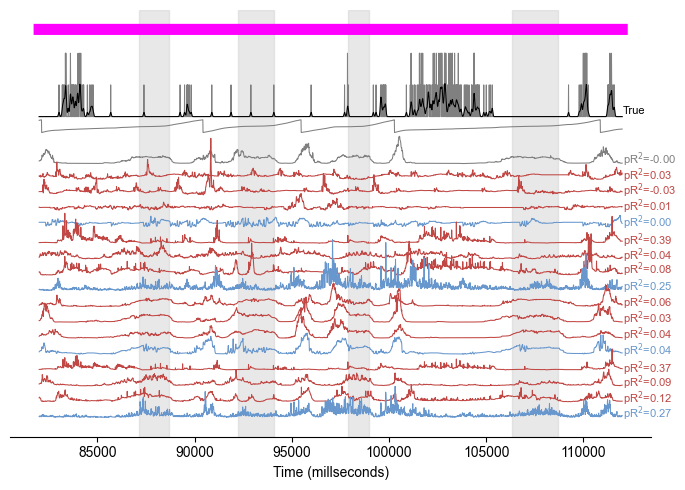

In [83]:
offset = 2  # vertical offset between traces

fig, ax = plt.subplots(figsize=(7, 5))
start=8000+200
end=11000+200
sf = -8 # scale factor for the y-axis
lw = 0.75
y = np.array(tcs_time[test_grid_cell_id]) # target variable is the test grid cell
ax.plot(np.arange(len(y))[start:end]*time_bs, np.ones(len(y))[start:end] + (offset*-8), color='magenta', linewidth=8)

ax.plot(np.arange(len(y))[start:end]*time_bs, y[start:end]*sf*0.5 + (offset*-2), label='True', color='grey', linewidth=lw)
ax.plot(np.arange(len(y))[start:end]*time_bs, y_smoothed[start:end]*sf*0.5 + (offset*-2), label='True', color='black', linewidth=lw)
ax.plot(np.arange(len(X))[start:end]*time_bs, X[start:end]*sf*0.001 + (offset*-1), label='True', color='grey', linewidth=lw)

ax.plot(np.arange(len(Y_hat_p_trainTA_testTI_))[start:end]*time_bs, Y_hat_p_trainTA_testTI_[start:end]*sf + offset, color='tab:grey', linewidth=lw, label='Position')
ax.plot(np.arange(len(Y_hat_g1_trainTA_testTI_))[start:end]*time_bs, Y_hat_g1_trainTA_testTI_[start:end]*sf + (offset*2), color='#c04744', linewidth=lw, label='Grid cell 10')
ax.plot(np.arange(len(Y_hat_g2_trainTA_testTI_))[start:end]*time_bs, Y_hat_g2_trainTA_testTI_[start:end]*sf + (offset*3), color='#c04744', linewidth=lw, label='Grid cell 11')
ax.plot(np.arange(len(Y_hat_g3_trainTA_testTI_))[start:end]*time_bs, Y_hat_g3_trainTA_testTI_[start:end]*sf + (offset*4), color='#c04744', linewidth=lw, label='Grid cell 12')
ax.plot(np.arange(len(Y_hat_ngs4_trainTA_testTI_))[start:end]*time_bs, Y_hat_ngs4_trainTA_testTI_[start:end]*sf + (offset*5), color='#6897CD', linewidth=lw, label='Grid cells module 1')
ax.plot(np.arange(len(Y_hat_m1_trainTA_testTI_))[start:end]*time_bs, Y_hat_m1_trainTA_testTI_[start:end]*sf + (offset*6), color='#c04744', linewidth=lw, label='Non-grid spatial cell 2')
ax.plot(np.arange(len(Y_hat_m2_trainTA_testTI_))[start:end]*time_bs, Y_hat_m2_trainTA_testTI_[start:end]*sf + (offset*7), color='#c04744', linewidth=lw, label='Non-grid spatial cell 3')
ax.plot(np.arange(len(Y_hat_m3_trainTA_testTI_))[start:end]*time_bs, Y_hat_m3_trainTA_testTI_[start:end]*sf + (offset*8), color='#c04744', linewidth=lw, label='Non-grid spatial cells module 2')
ax.plot(np.arange(len(Y_hat_ngs_trainTA_testTI_))[start:end]*time_bs, Y_hat_ngs_trainTA_testTI_[start:end]*sf + (offset*9), color='#6897CD', linewidth=lw, label='Non-grid spatial cells')
ax.plot(np.arange(len(Y_hat_pos_g1_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_g1_trainTA_testTI_[start:end]*sf + (offset*10), color='#c04744', linewidth=lw, label='Grid cell 10 + Position')
ax.plot(np.arange(len(Y_hat_pos_g2_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_g2_trainTA_testTI_[start:end]*sf + (offset*11), color='#c04744', linewidth=lw, label='Grid cell 11 + Position')
ax.plot(np.arange(len(Y_hat_pos_g3_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_g3_trainTA_testTI_[start:end]*sf + (offset*12), color='#c04744', linewidth=lw, label='Grid cell 12 + Position')
ax.plot(np.arange(len(Y_hat_pos_ngs4_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_ngs4_trainTA_testTI_[start:end]*sf + (offset*13), color='#6897CD', linewidth=lw, label='Non-grid spatial cell 2 + Position')
ax.plot(np.arange(len(Y_hat_pos_m1_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_m1_trainTA_testTI_[start:end]*sf + (offset*14), color='#c04744', linewidth=lw, label='Non-grid spatial cell 3 + Position')
ax.plot(np.arange(len(Y_hat_pos_m2_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_m2_trainTA_testTI_[start:end]*sf + (offset*15), color='#c04744', linewidth=lw, label='Non-grid spatial cells module 2 + Position')
ax.plot(np.arange(len(Y_hat_pos_m3_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_m3_trainTA_testTI_[start:end]*sf + (offset*16), color='#c04744', linewidth=lw, label='Non-grid spatial cells module 3 + Position')
ax.plot(np.arange(len(Y_hat_pos_ngs_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_ngs_trainTA_testTI_[start:end]*sf + (offset*17), color='#6897CD', linewidth=lw, label='Non-grid spatial cells + Position')
ax.set_xlabel('Time (millseconds)')

# Annotate mean pR² values with superscript
ax.text(end*time_bs + 10, np.mean(y[start:end]*sf + (offset*-2)), 'True', va='center', fontsize=8, color='black')
ax.text(end*time_bs + 10, np.mean(Y_hat_p_trainTA_testTI_[start:end]*sf + offset), f'pR$^2$={np.nanmean(pR2_condition_cv_trainTA_testTI):.2f}', va='center', fontsize=8, color='tab:grey')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_trainTA_testTI_[start:end]*sf + (offset*2)), f'pR$^2$={np.nanmean(pR2_condition_cv_g1_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_g2_trainTA_testTI_[start:end]*sf + (offset*3)), f'pR$^2$={np.nanmean(pR2_condition_cv_g2_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_g3_trainTA_testTI_[start:end]*sf + (offset*4)), f'pR$^2$={np.nanmean(pR2_condition_cv_g3_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs4_trainTA_testTI_[start:end]*sf + (offset*5)), f'pR$^2$={np.nanmean(pR2_condition_cv_ngs4_trainTA_testTI):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_m1_trainTA_testTI_[start:end]*sf + (offset*6)), f'pR$^2$={np.nanmean(pR2_condition_cv_m1_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_m2_trainTA_testTI_[start:end]*sf + (offset*7)), f'pR$^2$={np.nanmean(pR2_condition_cv_m2_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_m3_trainTA_testTI_[start:end]*sf + (offset*8)), f'pR$^2$={np.nanmean(pR2_condition_cv_m3_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs_trainTA_testTI_[start:end]*sf + (offset*9)), f'pR$^2$={np.nanmean(pR2_condition_cv_ngs_trainTA_testTI):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g1_trainTA_testTI_[start:end]*sf + (offset*10)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_g1_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g2_trainTA_testTI_[start:end]*sf + (offset*11)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_g2_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g3_trainTA_testTI_[start:end]*sf + (offset*12)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_g3_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs4_trainTA_testTI_[start:end]*sf + (offset*13)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_ngs4_trainTA_testTI):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_m1_trainTA_testTI_[start:end]*sf + (offset*14)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_m1_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_m2_trainTA_testTI_[start:end]*sf + (offset*15)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_m2_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_m3_trainTA_testTI_[start:end]*sf + (offset*16)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_m3_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs_trainTA_testTI_[start:end]*sf + (offset*17)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_ngs_trainTA_testTI):.2f}', va='center', fontsize=8, color='#6897CD')

# Find indices where X[start:end] is between 90 and 110
mask = (X[start:end].flatten() >= 90) & (X[start:end].flatten() <= 110)
if np.any(mask):
    xvals = np.arange(len(X))[start:end][mask] * time_bs
    # Shade the region(s) where the mask is True
    # If there are multiple contiguous regions, shade each
    from itertools import groupby
    from operator import itemgetter

    # Find contiguous regions
    idx = np.where(mask)[0]
    for k, g in groupby(enumerate(idx), lambda ix: ix[0] - ix[1]):
        group = list(map(itemgetter(1), g))
        x_start = np.arange(len(X))[start:end][group[0]] * time_bs
        x_end = np.arange(len(X))[start:end][group[-1]] * time_bs
        ax.axvspan(x_start, x_end, color='lightgrey', alpha=0.5, zorder=0)

#ax.legend()
# remove top, left and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticklabels([])
ax.set_yticks([])
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_xgboost_TA_TI_models.pdf', bbox_inches='tight', dpi=500) # use tight layout to avoid cutting off labels
plt.show()


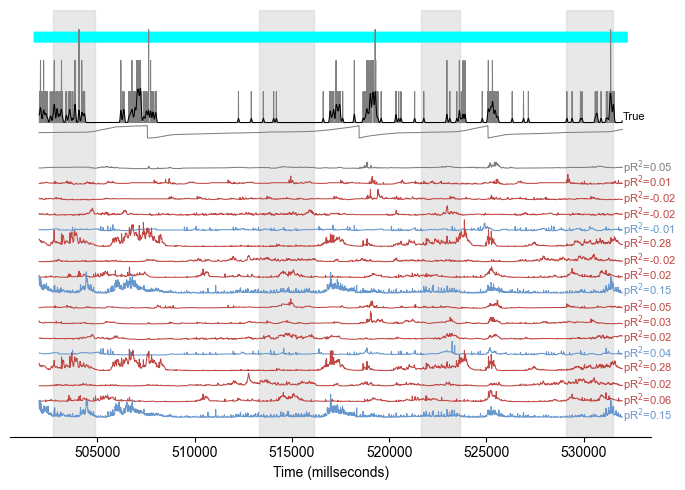

In [84]:
offset = 2  # vertical offset between traces

fig, ax = plt.subplots(figsize=(7, 5))
start = 50000 + 200
end = 53000 + 200
sf = -8  # scale factor for the y-axis
lw = 0.75
y = np.array(tcs_time[test_grid_cell_id])  # target variable is the test grid cell
ax.plot(np.arange(len(y))[start:end]*time_bs, np.ones(len(y))[start:end] + (offset*-8), color='cyan', linewidth=8)

ax.plot(np.arange(len(y))[start:end]*time_bs, y[start:end]*sf*0.5 + (offset*-2), label='True', color='grey', linewidth=lw)
ax.plot(np.arange(len(y))[start:end]*time_bs, y_smoothed[start:end]*sf*0.5 + (offset*-2), label='True', color='black', linewidth=lw)

ax.plot(np.arange(len(X))[start:end]*time_bs, X[start:end]*sf*0.001 + (offset*-1), label='True', color='grey', linewidth=lw)

ax.plot(np.arange(len(Y_hat_p_trainTI_testTA_))[start:end]*time_bs, Y_hat_p_trainTI_testTA_[start:end]*sf + offset, color='tab:grey', linewidth=lw, label='Position')
ax.plot(np.arange(len(Y_hat_g1_trainTI_testTA_))[start:end]*time_bs, Y_hat_g1_trainTI_testTA_[start:end]*sf + (offset*2), color='#c04744', linewidth=lw, label='Grid cell 10')
ax.plot(np.arange(len(Y_hat_g2_trainTI_testTA_))[start:end]*time_bs, Y_hat_g2_trainTI_testTA_[start:end]*sf + (offset*3), color='#c04744', linewidth=lw, label='Grid cell 11')
ax.plot(np.arange(len(Y_hat_g3_trainTI_testTA_))[start:end]*time_bs, Y_hat_g3_trainTI_testTA_[start:end]*sf + (offset*4), color='#c04744', linewidth=lw, label='Grid cell 12')
ax.plot(np.arange(len(Y_hat_ngs4_trainTI_testTA_))[start:end]*time_bs, Y_hat_ngs4_trainTI_testTA_[start:end]*sf + (offset*5), color='#6897CD', linewidth=lw, label='Grid cells module 1')
ax.plot(np.arange(len(Y_hat_m1_trainTI_testTA_))[start:end]*time_bs, Y_hat_m1_trainTI_testTA_[start:end]*sf + (offset*6), color='#c04744', linewidth=lw, label='Non-grid spatial cell 2')
ax.plot(np.arange(len(Y_hat_m2_trainTI_testTA_))[start:end]*time_bs, Y_hat_m2_trainTI_testTA_[start:end]*sf + (offset*7), color='#c04744', linewidth=lw, label='Non-grid spatial cell 3')
ax.plot(np.arange(len(Y_hat_m3_trainTI_testTA_))[start:end]*time_bs, Y_hat_m3_trainTI_testTA_[start:end]*sf + (offset*8), color='#c04744', linewidth=lw, label='Non-grid spatial cells module 2')
ax.plot(np.arange(len(Y_hat_ngs_trainTI_testTA_))[start:end]*time_bs, Y_hat_ngs_trainTI_testTA_[start:end]*sf + (offset*9), color='#6897CD', linewidth=lw, label='Non-grid spatial cells')
ax.plot(np.arange(len(Y_hat_pos_g1_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_g1_trainTI_testTA_[start:end]*sf + (offset*10), color='#c04744', linewidth=lw, label='Grid cell 10 + Position')
ax.plot(np.arange(len(Y_hat_pos_g2_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_g2_trainTI_testTA_[start:end]*sf + (offset*11), color='#c04744', linewidth=lw, label='Grid cell 11 + Position')
ax.plot(np.arange(len(Y_hat_pos_g3_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_g3_trainTI_testTA_[start:end]*sf + (offset*12), color='#c04744', linewidth=lw, label='Grid cell 12 + Position')
ax.plot(np.arange(len(Y_hat_pos_ngs4_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_ngs4_trainTI_testTA_[start:end]*sf + (offset*13), color='#6897CD', linewidth=lw, label='Non-grid spatial cell 2 + Position')
ax.plot(np.arange(len(Y_hat_pos_m1_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_m1_trainTI_testTA_[start:end]*sf + (offset*14), color='#c04744', linewidth=lw, label='Non-grid spatial cell 3 + Position')
ax.plot(np.arange(len(Y_hat_pos_m2_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_m2_trainTI_testTA_[start:end]*sf + (offset*15), color='#c04744', linewidth=lw, label='Non-grid spatial cells module 2 + Position')
ax.plot(np.arange(len(Y_hat_pos_m3_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_m3_trainTI_testTA_[start:end]*sf + (offset*16), color='#c04744', linewidth=lw, label='Non-grid spatial cells module 3 + Position')
ax.plot(np.arange(len(Y_hat_pos_ngs_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_ngs_trainTI_testTA_[start:end]*sf + (offset*17), color='#6897CD', linewidth=lw, label='Non-grid spatial cells + Position')
ax.set_xlabel('Time (millseconds)')

# Annotate mean pR² values with superscript (swap TA <-> TI)
ax.text(end*time_bs + 10, np.mean(y[start:end]*sf + (offset*-2)), 'True', va='center', fontsize=8, color='black')
ax.text(end*time_bs + 10, np.mean(Y_hat_p_trainTI_testTA_[start:end]*sf + offset), f'pR$^2$={np.nanmean(pR2_condition_cv_trainTI_testTA):.2f}', va='center', fontsize=8, color='tab:grey')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_trainTI_testTA_[start:end]*sf + (offset*2)), f'pR$^2$={np.nanmean(pR2_condition_cv_g1_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_g2_trainTI_testTA_[start:end]*sf + (offset*3)), f'pR$^2$={np.nanmean(pR2_condition_cv_g2_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_g3_trainTI_testTA_[start:end]*sf + (offset*4)), f'pR$^2$={np.nanmean(pR2_condition_cv_g3_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs4_trainTI_testTA_[start:end]*sf + (offset*5)), f'pR$^2$={np.nanmean(pR2_condition_cv_ngs4_trainTI_testTA):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_m1_trainTI_testTA_[start:end]*sf + (offset*6)), f'pR$^2$={np.nanmean(pR2_condition_cv_m1_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_m2_trainTI_testTA_[start:end]*sf + (offset*7)), f'pR$^2$={np.nanmean(pR2_condition_cv_m2_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_m3_trainTI_testTA_[start:end]*sf + (offset*8)), f'pR$^2$={np.nanmean(pR2_condition_cv_m3_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs_trainTI_testTA_[start:end]*sf + (offset*9)), f'pR$^2$={np.nanmean(pR2_condition_cv_ngs_trainTI_testTA):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g1_trainTI_testTA_[start:end]*sf + (offset*10)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_g1_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g2_trainTI_testTA_[start:end]*sf + (offset*11)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_g2_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g3_trainTI_testTA_[start:end]*sf + (offset*12)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_g3_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs4_trainTI_testTA_[start:end]*sf + (offset*13)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_ngs4_trainTI_testTA):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_m1_trainTI_testTA_[start:end]*sf + (offset*14)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_m1_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_m2_trainTI_testTA_[start:end]*sf + (offset*15)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_m2_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_m3_trainTI_testTA_[start:end]*sf + (offset*16)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_m3_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs_trainTI_testTA_[start:end]*sf + (offset*17)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_ngs_trainTI_testTA):.2f}', va='center', fontsize=8, color='#6897CD')

# Find indices where X[start:end] is between 90 and 110
mask = (X[start:end].flatten() >= 90) & (X[start:end].flatten() <= 110)
if np.any(mask):
    xvals = np.arange(len(X))[start:end][mask] * time_bs
    # Shade the region(s) where the mask is True
    from itertools import groupby
    from operator import itemgetter

    # Find contiguous regions
    idx = np.where(mask)[0]
    for k, g in groupby(enumerate(idx), lambda ix: ix[0] - ix[1]):
        group = list(map(itemgetter(1), g))
        x_start = np.arange(len(X))[start:end][group[0]] * time_bs
        x_end = np.arange(len(X))[start:end][group[-1]] * time_bs
        ax.axvspan(x_start, x_end, color='lightgrey', alpha=0.5, zorder=0)

#ax.legend()
# remove top, left and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticklabels([])
ax.set_yticks([])
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_xgboost_TI_TA_models.pdf', bbox_inches='tight', dpi=500) # use tight layout to avoid cutting off labels
plt.show()

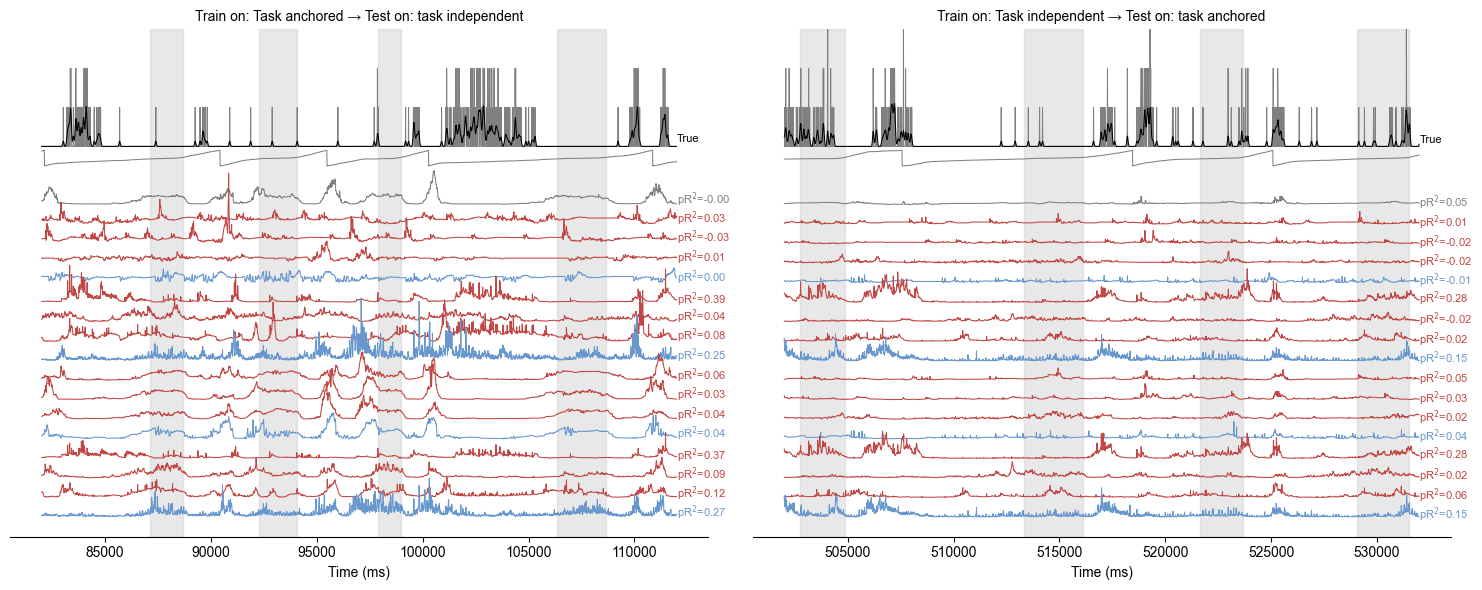

: 

In [ ]:
# Combine the two plots into a single figure with two subplots (side by side)

offset = 2  # vertical offset between traces
sf = -8  # scale factor for the y-axis
lw = 0.75

fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# --- First subplot: TA->TI (magenta bar) ---
ax = axs[0]
start = 8000 + 200
end = 11000 + 200
y = np.array(tcs_time[test_grid_cell_id])

ax.plot(np.arange(len(y))[start:end]*time_bs, y[start:end]*sf*0.5 + (offset*-2), label='True', color='grey', linewidth=lw)
ax.plot(np.arange(len(y))[start:end]*time_bs, y_smoothed[start:end]*sf*0.5 + (offset*-2), label='True', color='black', linewidth=lw)
ax.plot(np.arange(len(X))[start:end]*time_bs, X[start:end]*sf*0.001 + (offset*-1), label='True', color='grey', linewidth=lw)

ax.plot(np.arange(len(Y_hat_p_trainTA_testTI_))[start:end]*time_bs, Y_hat_p_trainTA_testTI_[start:end]*sf + offset, color='tab:grey', linewidth=lw, label='Position')
ax.plot(np.arange(len(Y_hat_g1_trainTA_testTI_))[start:end]*time_bs, Y_hat_g1_trainTA_testTI_[start:end]*sf + (offset*2), color='#c04744', linewidth=lw, label='Grid cell 10')
ax.plot(np.arange(len(Y_hat_g2_trainTA_testTI_))[start:end]*time_bs, Y_hat_g2_trainTA_testTI_[start:end]*sf + (offset*3), color='#c04744', linewidth=lw, label='Grid cell 11')
ax.plot(np.arange(len(Y_hat_g3_trainTA_testTI_))[start:end]*time_bs, Y_hat_g3_trainTA_testTI_[start:end]*sf + (offset*4), color='#c04744', linewidth=lw, label='Grid cell 12')
ax.plot(np.arange(len(Y_hat_ngs4_trainTA_testTI_))[start:end]*time_bs, Y_hat_ngs4_trainTA_testTI_[start:end]*sf + (offset*5), color='#6897CD', linewidth=lw, label='Grid cells module 1')
ax.plot(np.arange(len(Y_hat_m1_trainTA_testTI_))[start:end]*time_bs, Y_hat_m1_trainTA_testTI_[start:end]*sf + (offset*6), color='#c04744', linewidth=lw, label='Non-grid spatial cell 2')
ax.plot(np.arange(len(Y_hat_m2_trainTA_testTI_))[start:end]*time_bs, Y_hat_m2_trainTA_testTI_[start:end]*sf + (offset*7), color='#c04744', linewidth=lw, label='Non-grid spatial cell 3')
ax.plot(np.arange(len(Y_hat_m3_trainTA_testTI_))[start:end]*time_bs, Y_hat_m3_trainTA_testTI_[start:end]*sf + (offset*8), color='#c04744', linewidth=lw, label='Non-grid spatial cells module 2')
ax.plot(np.arange(len(Y_hat_ngs_trainTA_testTI_))[start:end]*time_bs, Y_hat_ngs_trainTA_testTI_[start:end]*sf + (offset*9), color='#6897CD', linewidth=lw, label='Non-grid spatial cells')
ax.plot(np.arange(len(Y_hat_pos_g1_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_g1_trainTA_testTI_[start:end]*sf + (offset*10), color='#c04744', linewidth=lw, label='Grid cell 10 + Position')
ax.plot(np.arange(len(Y_hat_pos_g2_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_g2_trainTA_testTI_[start:end]*sf + (offset*11), color='#c04744', linewidth=lw, label='Grid cell 11 + Position')
ax.plot(np.arange(len(Y_hat_pos_g3_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_g3_trainTA_testTI_[start:end]*sf + (offset*12), color='#c04744', linewidth=lw, label='Grid cell 12 + Position')
ax.plot(np.arange(len(Y_hat_pos_ngs4_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_ngs4_trainTA_testTI_[start:end]*sf + (offset*13), color='#6897CD', linewidth=lw, label='Non-grid spatial cell 2 + Position')
ax.plot(np.arange(len(Y_hat_pos_m1_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_m1_trainTA_testTI_[start:end]*sf + (offset*14), color='#c04744', linewidth=lw, label='Non-grid spatial cell 3 + Position')
ax.plot(np.arange(len(Y_hat_pos_m2_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_m2_trainTA_testTI_[start:end]*sf + (offset*15), color='#c04744', linewidth=lw, label='Non-grid spatial cells module 2 + Position')
ax.plot(np.arange(len(Y_hat_pos_m3_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_m3_trainTA_testTI_[start:end]*sf + (offset*16), color='#c04744', linewidth=lw, label='Non-grid spatial cells module 3 + Position')
ax.plot(np.arange(len(Y_hat_pos_ngs_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_ngs_trainTA_testTI_[start:end]*sf + (offset*17), color='#6897CD', linewidth=lw, label='Non-grid spatial cells + Position')
ax.set_xlabel('Time (ms)')
ax.set_title('Train on: Task anchored → Test on: task independent', fontsize=10)

# Annotate mean pR² values
ax.text(end*time_bs + 10, np.mean(y[start:end]*sf + (offset*-2)), 'True', va='center', fontsize=8, color='black')
ax.text(end*time_bs + 10, np.mean(Y_hat_p_trainTA_testTI_[start:end]*sf + offset), f'pR$^2$={np.nanmean(pR2_condition_cv_trainTA_testTI):.2f}', va='center', fontsize=8, color='tab:grey')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_trainTA_testTI_[start:end]*sf + (offset*2)), f'pR$^2$={np.nanmean(pR2_condition_cv_g1_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_g2_trainTA_testTI_[start:end]*sf + (offset*3)), f'pR$^2$={np.nanmean(pR2_condition_cv_g2_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_g3_trainTA_testTI_[start:end]*sf + (offset*4)), f'pR$^2$={np.nanmean(pR2_condition_cv_g3_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs4_trainTA_testTI_[start:end]*sf + (offset*5)), f'pR$^2$={np.nanmean(pR2_condition_cv_ngs4_trainTA_testTI):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_m1_trainTA_testTI_[start:end]*sf + (offset*6)), f'pR$^2$={np.nanmean(pR2_condition_cv_m1_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_m2_trainTA_testTI_[start:end]*sf + (offset*7)), f'pR$^2$={np.nanmean(pR2_condition_cv_m2_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_m3_trainTA_testTI_[start:end]*sf + (offset*8)), f'pR$^2$={np.nanmean(pR2_condition_cv_m3_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs_trainTA_testTI_[start:end]*sf + (offset*9)), f'pR$^2$={np.nanmean(pR2_condition_cv_ngs_trainTA_testTI):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g1_trainTA_testTI_[start:end]*sf + (offset*10)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_g1_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g2_trainTA_testTI_[start:end]*sf + (offset*11)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_g2_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g3_trainTA_testTI_[start:end]*sf + (offset*12)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_g3_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs4_trainTA_testTI_[start:end]*sf + (offset*13)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_ngs4_trainTA_testTI):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_m1_trainTA_testTI_[start:end]*sf + (offset*14)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_m1_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_m2_trainTA_testTI_[start:end]*sf + (offset*15)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_m2_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_m3_trainTA_testTI_[start:end]*sf + (offset*16)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_m3_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs_trainTA_testTI_[start:end]*sf + (offset*17)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_ngs_trainTA_testTI):.2f}', va='center', fontsize=8, color='#6897CD')

# Shade regions where X is between 90 and 110
mask = (X[start:end].flatten() >= 90) & (X[start:end].flatten() <= 110)
if np.any(mask):
    from itertools import groupby
    from operator import itemgetter
    idx = np.where(mask)[0]
    for k, g in groupby(enumerate(idx), lambda ix: ix[0] - ix[1]):
        group = list(map(itemgetter(1), g))
        x_start = np.arange(len(X))[start:end][group[0]] * time_bs
        x_end = np.arange(len(X))[start:end][group[-1]] * time_bs
        ax.axvspan(x_start, x_end, color='lightgrey', alpha=0.5, zorder=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticklabels([])
ax.set_yticks([])
ax.invert_yaxis()
ax.set_ylim(offset*-8, offset*18)

# --- Second subplot: TI->TA (cyan bar) ---
ax = axs[1]
start = 50000 + 200
end = 53000 + 200
y = np.array(tcs_time[test_grid_cell_id])
ax.plot(np.arange(len(y))[start:end]*time_bs, y[start:end]*sf*0.5 + (offset*-2), label='True', color='grey', linewidth=lw)
ax.plot(np.arange(len(y))[start:end]*time_bs, y_smoothed[start:end]*sf*0.5 + (offset*-2), label='True', color='black', linewidth=lw)
ax.plot(np.arange(len(X))[start:end]*time_bs, X[start:end]*sf*0.001 + (offset*-1), label='True', color='grey', linewidth=lw)

ax.plot(np.arange(len(Y_hat_p_trainTI_testTA_))[start:end]*time_bs, Y_hat_p_trainTI_testTA_[start:end]*sf + offset, color='tab:grey', linewidth=lw, label='Position')
ax.plot(np.arange(len(Y_hat_g1_trainTI_testTA_))[start:end]*time_bs, Y_hat_g1_trainTI_testTA_[start:end]*sf + (offset*2), color='#c04744', linewidth=lw, label='Grid cell 10')
ax.plot(np.arange(len(Y_hat_g2_trainTI_testTA_))[start:end]*time_bs, Y_hat_g2_trainTI_testTA_[start:end]*sf + (offset*3), color='#c04744', linewidth=lw, label='Grid cell 11')
ax.plot(np.arange(len(Y_hat_g3_trainTI_testTA_))[start:end]*time_bs, Y_hat_g3_trainTI_testTA_[start:end]*sf + (offset*4), color='#c04744', linewidth=lw, label='Grid cell 12')
ax.plot(np.arange(len(Y_hat_ngs4_trainTI_testTA_))[start:end]*time_bs, Y_hat_ngs4_trainTI_testTA_[start:end]*sf + (offset*5), color='#6897CD', linewidth=lw, label='Grid cells module 1')
ax.plot(np.arange(len(Y_hat_m1_trainTI_testTA_))[start:end]*time_bs, Y_hat_m1_trainTI_testTA_[start:end]*sf + (offset*6), color='#c04744', linewidth=lw, label='Non-grid spatial cell 2')
ax.plot(np.arange(len(Y_hat_m2_trainTI_testTA_))[start:end]*time_bs, Y_hat_m2_trainTI_testTA_[start:end]*sf + (offset*7), color='#c04744', linewidth=lw, label='Non-grid spatial cell 3')
ax.plot(np.arange(len(Y_hat_m3_trainTI_testTA_))[start:end]*time_bs, Y_hat_m3_trainTI_testTA_[start:end]*sf + (offset*8), color='#c04744', linewidth=lw, label='Non-grid spatial cells module 2')
ax.plot(np.arange(len(Y_hat_ngs_trainTI_testTA_))[start:end]*time_bs, Y_hat_ngs_trainTI_testTA_[start:end]*sf + (offset*9), color='#6897CD', linewidth=lw, label='Non-grid spatial cells')
ax.plot(np.arange(len(Y_hat_pos_g1_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_g1_trainTI_testTA_[start:end]*sf + (offset*10), color='#c04744', linewidth=lw, label='Grid cell 10 + Position')
ax.plot(np.arange(len(Y_hat_pos_g2_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_g2_trainTI_testTA_[start:end]*sf + (offset*11), color='#c04744', linewidth=lw, label='Grid cell 11 + Position')
ax.plot(np.arange(len(Y_hat_pos_g3_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_g3_trainTI_testTA_[start:end]*sf + (offset*12), color='#c04744', linewidth=lw, label='Grid cell 12 + Position')
ax.plot(np.arange(len(Y_hat_pos_ngs4_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_ngs4_trainTI_testTA_[start:end]*sf + (offset*13), color='#6897CD', linewidth=lw, label='Non-grid spatial cell 2 + Position')
ax.plot(np.arange(len(Y_hat_pos_m1_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_m1_trainTI_testTA_[start:end]*sf + (offset*14), color='#c04744', linewidth=lw, label='Non-grid spatial cell 3 + Position')
ax.plot(np.arange(len(Y_hat_pos_m2_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_m2_trainTI_testTA_[start:end]*sf + (offset*15), color='#c04744', linewidth=lw, label='Non-grid spatial cells module 2 + Position')
ax.plot(np.arange(len(Y_hat_pos_m3_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_m3_trainTI_testTA_[start:end]*sf + (offset*16), color='#c04744', linewidth=lw, label='Non-grid spatial cells module 3 + Position')
ax.plot(np.arange(len(Y_hat_pos_ngs_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_ngs_trainTI_testTA_[start:end]*sf + (offset*17), color='#6897CD', linewidth=lw, label='Non-grid spatial cells + Position')
ax.set_xlabel('Time (ms)')
ax.set_title('Train on: Task independent → Test on: task anchored', fontsize=10)

# Annotate mean pR² values
ax.text(end*time_bs + 10, np.mean(y[start:end]*sf + (offset*-2)), 'True', va='center', fontsize=8, color='black')
ax.text(end*time_bs + 10, np.mean(Y_hat_p_trainTI_testTA_[start:end]*sf + offset), f'pR$^2$={np.nanmean(pR2_condition_cv_trainTI_testTA):.2f}', va='center', fontsize=8, color='tab:grey')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_trainTI_testTA_[start:end]*sf + (offset*2)), f'pR$^2$={np.nanmean(pR2_condition_cv_g1_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_g2_trainTI_testTA_[start:end]*sf + (offset*3)), f'pR$^2$={np.nanmean(pR2_condition_cv_g2_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_g3_trainTI_testTA_[start:end]*sf + (offset*4)), f'pR$^2$={np.nanmean(pR2_condition_cv_g3_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs4_trainTI_testTA_[start:end]*sf + (offset*5)), f'pR$^2$={np.nanmean(pR2_condition_cv_ngs4_trainTI_testTA):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_m1_trainTI_testTA_[start:end]*sf + (offset*6)), f'pR$^2$={np.nanmean(pR2_condition_cv_m1_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_m2_trainTI_testTA_[start:end]*sf + (offset*7)), f'pR$^2$={np.nanmean(pR2_condition_cv_m2_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_m3_trainTI_testTA_[start:end]*sf + (offset*8)), f'pR$^2$={np.nanmean(pR2_condition_cv_m3_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs_trainTI_testTA_[start:end]*sf + (offset*9)), f'pR$^2$={np.nanmean(pR2_condition_cv_ngs_trainTI_testTA):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g1_trainTI_testTA_[start:end]*sf + (offset*10)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_g1_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g2_trainTI_testTA_[start:end]*sf + (offset*11)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_g2_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g3_trainTI_testTA_[start:end]*sf + (offset*12)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_g3_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs4_trainTI_testTA_[start:end]*sf + (offset*13)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_ngs4_trainTI_testTA):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_m1_trainTI_testTA_[start:end]*sf + (offset*14)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_m1_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_m2_trainTI_testTA_[start:end]*sf + (offset*15)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_m2_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_m3_trainTI_testTA_[start:end]*sf + (offset*16)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_m3_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs_trainTI_testTA_[start:end]*sf + (offset*17)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_ngs_trainTI_testTA):.2f}', va='center', fontsize=8, color='#6897CD')

# Shade regions where X is between 90 and 110
mask = (X[start:end].flatten() >= 90) & (X[start:end].flatten() <= 110)
if np.any(mask):
    from itertools import groupby
    from operator import itemgetter
    idx = np.where(mask)[0]
    for k, g in groupby(enumerate(idx), lambda ix: ix[0] - ix[1]):
        group = list(map(itemgetter(1), g))
        x_start = np.arange(len(X))[start:end][group[0]] * time_bs
        x_end = np.arange(len(X))[start:end][group[-1]] * time_bs
        ax.axvspan(x_start, x_end, color='lightgrey', alpha=0.5, zorder=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticklabels([])
ax.set_yticks([])
ax.set_ylim(offset*-8, offset*18)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_xgboost_TA_TI_TI_TA_models_combined.pdf', bbox_inches='tight', dpi=500)
plt.show()

In [ ]:
labels_in_time = get_task_anchored_labels_in_time(mouse,day,cluster_ids_for_spectrogram=g_m_cluster_ids[0])

In [ ]:
labels_in_time.shape

In [ ]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import imageio

frames = []
gif_path = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/session_spectrogram.gif'

window_size = 1000
step_size = 100  # adjust for smoothness/speed
sf = -2
offset = 2
lw = 0.75

for s in range(0, len(y) - window_size, step_size):
    e = s + window_size
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(np.arange(len(y))[s:e]*time_bs, y[s:e]*sf, label='True', color='black', linewidth=lw)
    ax.plot(np.arange(len(Y_hat_p))[s:e]*time_bs, Y_hat_p[s:e]*sf + offset, color='tab:orange', linewidth=lw, label='Position')
    ax.plot(np.arange(len(Y_hat_cmg1))[s:e]*time_bs, Y_hat_cmg1[s:e]*sf + (offset*2), color='#CAC841', linewidth=lw, label='Grid cell 10')
    ax.plot(np.arange(len(Y_hat_ncmg1))[s:e]*time_bs, Y_hat_ncmg1[s:e]*sf + (offset*3), color='#92902C', linewidth=lw, label='Grid cell 10')
    ax.plot(np.arange(len(Y_hat_ngs1))[s:e]*time_bs, Y_hat_ngs1[s:e]*sf + (offset*4), color='#6897CD', linewidth=lw, label='NGS cell 2')
    ax.plot(np.arange(len(Y_hat_cmgmax))[s:e]*time_bs, Y_hat_cmgmax[s:e]*sf + (offset*5), color='#CAC841', linewidth=lw, label='Grid cells')
    ax.plot(np.arange(len(Y_hat_ncmgmax))[s:e]*time_bs, Y_hat_ncmgmax[s:e]*sf + (offset*6), color='#92902C', linewidth=lw, label='Grid cells')
    ax.plot(np.arange(len(Y_hat_ngsmax))[s:e]*time_bs, Y_hat_ngsmax[s:e]*sf + (offset*7), color='#6897CD', linewidth=lw, label='NGS cells')
    ax.plot(np.arange(len(Y_hat_pos_cmg1))[s:e]*time_bs, Y_hat_pos_cmg1[s:e]*sf + (offset*8), color='#CAC841', linewidth=lw, linestyle='--', label='Position + Grid cell 10')
    ax.plot(np.arange(len(Y_hat_pos_ncmg1))[s:e]*time_bs, Y_hat_pos_ncmg1[s:e]*sf + (offset*9), color='#92902C', linewidth=lw, linestyle='--', label='Position + Grid cell 10')
    ax.plot(np.arange(len(Y_hat_pos_ngs1))[s:e]*time_bs, Y_hat_pos_ngs1[s:e]*sf + (offset*10), color='#6897CD', linewidth=lw, linestyle='--', label='Position + NGS cell 2')
    ax.plot(np.arange(len(Y_hat_pos_cmgmax))[s:e]*time_bs, Y_hat_pos_cmgmax[s:e]*sf + (offset*11), color='#CAC841', linewidth=lw, linestyle='--', label='Position + Grid cells')
    ax.plot(np.arange(len(Y_hat_pos_ncmgmax))[s:e]*time_bs, Y_hat_pos_ncmgmax[s:e]*sf + (offset*12), color='#92902C', linewidth=lw, linestyle='--', label='Position + Grid cells')
    ax.plot(np.arange(len(Y_hat_pos_ngsmax))[s:e]*time_bs, Y_hat_pos_ngsmax[s:e]*sf + (offset*13), color='#6897CD', linewidth=lw, linestyle='--', label='Position + NGS cells')
    ax.set_xlabel('Time (millseconds)')

    # Scatter for labels_in_time
    label_vals = labels_in_time[s:e]
    cmap = cm.get_cmap('cool')
    scatter_y = np.full_like(label_vals, np.max(y[s:e]*sf) - 6)
    ax.scatter(np.arange(len(y))[s:e]*time_bs, scatter_y, c=label_vals, cmap=cmap, s=10, vmin=0, vmax=1, marker='|', linewidths=2)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.invert_yaxis()
    plt.tight_layout()

    # Save frame to buffer using fig.canvas.buffer_rgba()
    fig.canvas.draw()
    frame = np.asarray(fig.canvas.buffer_rgba())
    frames.append(frame)
    plt.close(fig)

# Save as GIF
imageio.mimsave(gif_path, frames, duration=0.15)
print(f"GIF saved to {gif_path}")

In [ ]:
import matplotlib.cm as cm

pairs = [(48316-1500, 49316+500), (121441-500, 122441+1500)]
labels = ['task_anchored', 'task_independent']
window_size = 3000  # changed from 1000 to 2000
n_variations = 1
variation_range = 500

for (start, end), label in zip(pairs, labels):
    offsets = np.linspace(-variation_range, variation_range, n_variations, dtype=int)
    for v in offsets:
        s = start + v
        e = end + v
        # Ensure window size is 2000
        if s < 0 or e > len(y) or (e-s) != window_size:
            continue
        fig, ax = plt.subplots(figsize=(9, 5))  # wider plot
        offset = 2
        sf = -4
        true_sf = -2
        lw = 0.75

        # Plot traces
        ax.plot(np.arange(len(y))[s:e]*time_bs, y[s:e]*sf*0.5 + (offset*-1), label='True', color='grey', linewidth=lw)
        ax.plot(np.arange(len(y))[s:e]*time_bs, y_smoothed[s:e]*sf*0.5 + (offset*-1), label='True', color='black', linewidth=lw)
        ax.plot(np.arange(s, e)*time_bs, Y_hat_p[s:e]*sf + offset, color='tab:grey', linewidth=lw, label='Position')
        ax.plot(np.arange(s, e)*time_bs, Y_hat_cmg1[s:e]*sf + (offset*2), color='#CAC841', linewidth=lw, label='Grid cell 10')
        ax.plot(np.arange(s, e)*time_bs, Y_hat_ncmg1[s:e]*sf + (offset*3), color='#92902C', linewidth=lw, label='Grid cell 10')
        ax.plot(np.arange(s, e)*time_bs, Y_hat_ngs1[s:e]*sf + (offset*4), color='#6897CD', linewidth=lw, label='NGS cell 2')
        ax.plot(np.arange(s, e)*time_bs, Y_hat_cmgmax[s:e]*sf + (offset*5), color='#CAC841', linewidth=lw, label='Grid cells')
        ax.plot(np.arange(s, e)*time_bs, Y_hat_ncmgmax[s:e]*sf + (offset*6), color='#92902C', linewidth=lw, label='Grid cells')
        ax.plot(np.arange(s, e)*time_bs, Y_hat_ngsmax[s:e]*sf + (offset*7), color='#6897CD', linewidth=lw, label='NGS cells')
        ax.plot(np.arange(s, e)*time_bs, Y_hat_pos_cmg1[s:e]*sf + (offset*8), color='#CAC841', linewidth=lw, label='Position + Grid cell 10')
        ax.plot(np.arange(s, e)*time_bs, Y_hat_pos_ncmg1[s:e]*sf + (offset*9), color='#92902C', linewidth=lw, label='Position + Grid cell 10')
        ax.plot(np.arange(s, e)*time_bs, Y_hat_pos_ngs1[s:e]*sf + (offset*10), color='#6897CD', linewidth=lw, label='Position + NGS cell 2')
        ax.plot(np.arange(s, e)*time_bs, Y_hat_pos_cmgmax[s:e]*sf + (offset*11), color='#CAC841', linewidth=lw, label='Position + Grid cells')
        ax.plot(np.arange(s, e)*time_bs, Y_hat_pos_ncmgmax[s:e]*sf + (offset*12), color='#92902C', linewidth=lw, label='Position + Grid cells')
        ax.plot(np.arange(s, e)*time_bs, Y_hat_pos_ngsmax[s:e]*sf + (offset*13), color='#6897CD', linewidth=lw, label='Position + NGS cells')
        ax.set_xlabel('Time (millseconds)')

        # Scatter for labels_in_time
        label_vals = labels_in_time[s:e]
        cmap = cm.get_cmap('cool')
        scatter_y = np.full_like(label_vals, np.max(y[s:e]*sf) - 6)
        ax.scatter(np.arange(s, e)*time_bs, scatter_y, c=label_vals, cmap=cmap, s=10, vmin=0, vmax=1, marker='|', linewidths=2)

        # Annotate mean pR² values with superscript
        ax.text(e*time_bs + 10, np.mean(y[s:e]*sf), 'True', va='center', fontsize=8, color='black')
        ax.text(e*time_bs + 10, np.mean(Y_hat_p[s:e]*sf + offset), f'pR$^2$={np.nanmean(pR2_cv_p):.2f}', va='center', fontsize=8, color='tab:grey')
        ax.text(e*time_bs + 10, np.mean(Y_hat_cmg1[s:e]*sf + (offset*2)), f'pR$^2$={np.nanmean(pR2_cv_cmg1):.2f}', va='center', fontsize=8, color='#CAC841')
        ax.text(e*time_bs + 10, np.mean(Y_hat_ncmg1[s:e]*sf + (offset*3)), f'pR$^2$={np.nanmean(pR2_cv_ncmg1):.2f}', va='center', fontsize=8, color='#92902C')
        ax.text(e*time_bs + 10, np.mean(Y_hat_ngs1[s:e]*sf + (offset*4)), f'pR$^2$={np.nanmean(pR2_cv_ngs1):.2f}', va='center', fontsize=8, color='#6897CD')
        ax.text(e*time_bs + 10, np.mean(Y_hat_cmgmax[s:e]*sf + (offset*5)), f'pR$^2$={np.nanmean(pR2_cv_cmgmax):.2f}', va='center', fontsize=8, color='#CAC841')
        ax.text(e*time_bs + 10, np.mean(Y_hat_ncmgmax[s:e]*sf + (offset*6)), f'pR$^2$={np.nanmean(pR2_cv_ncmgmax):.2f}', va='center', fontsize=8, color='#92902C')
        ax.text(e*time_bs + 10, np.mean(Y_hat_ngsmax[s:e]*sf + (offset*7)), f'pR$^2$={np.nanmean(pR2_cv_ngsmax):.2f}', va='center', fontsize=8, color='#6897CD')
        ax.text(e*time_bs + 10, np.mean(Y_hat_pos_cmg1[s:e]*sf + (offset*8)), f'pR$^2$={np.nanmean(pR2_cv_pos_cmg1):.2f}', va='center', fontsize=8, color='#CAC841')
        ax.text(e*time_bs + 10, np.mean(Y_hat_pos_ncmg1[s:e]*sf + (offset*9)), f'pR$^2$={np.nanmean(pR2_cv_pos_ncmg1):.2f}', va='center', fontsize=8, color='#92902C')
        ax.text(e*time_bs + 10, np.mean(Y_hat_pos_ngs1[s:e]*sf + (offset*10)), f'pR$^2$={np.nanmean(pR2_cv_pos_ngs1):.2f}', va='center', fontsize=8, color='#6897CD')
        ax.text(e*time_bs + 10, np.mean(Y_hat_pos_cmgmax[s:e]*sf + (offset*11)), f'pR$^2$={np.nanmean(pR2_cv_pos_cmgmax):.2f}', va='center', fontsize=8, color='#CAC841')
        ax.text(e*time_bs + 10, np.mean(Y_hat_pos_ncmgmax[s:e]*sf + (offset*12)), f'pR$^2$={np.nanmean(pR2_cv_pos_ncmgmax):.2f}', va='center', fontsize=8, color='#92902C')
        ax.text(e*time_bs + 10, np.mean(Y_hat_pos_ngsmax[s:e]*sf + (offset*13)), f'pR$^2$={np.nanmean(pR2_cv_pos_ngsmax):.2f}', va='center', fontsize=8, color='#6897CD')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.set_yticklabels([])
        ax.set_yticks([])
        ax.invert_yaxis()
        plt.tight_layout()
        plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_xgboost_prediction_{start}_{end}_v{v}_{label}.pdf', bbox_inches='tight')
        plt.show()

In [ ]:
figpath_rm = '/Users/harryclark/Desktop/M25D24'
plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day, cluster_ids=gcs.cluster_id.values, cluster_ids_for_spectrogram=g_m_cluster_ids[0], label='GC', figpath=figpath_rm)
plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day, cluster_ids=ngs.cluster_id.values, cluster_ids_for_spectrogram=g_m_cluster_ids[0], label='NGS', figpath=figpath_rm)

In [ ]:
import matplotlib.pyplot as plt

# Model names and predictions
model_names = [
    'Position', 'Grid cell 10', 'Grid cell 10 (ncm)', 'NGS cell 2', 'Grid cells', 'Grid cells (ncm)', 'NGS cells',
    'Position + Grid cell 10', 'Position + Grid cell 10 (ncm)', 'Position + NGS cell 2',
    'Position + Grid cells', 'Position + Grid cells (ncm)', 'Position + NGS cells'
]
model_vars = [
    Y_hat_p, Y_hat_cmg1, Y_hat_ncmg1, Y_hat_ngs1, Y_hat_cmgmax, Y_hat_ncmgmax, Y_hat_ngsmax,
    Y_hat_pos_cmg1, Y_hat_pos_ncmg1, Y_hat_pos_ngs1,
    Y_hat_pos_cmgmax, Y_hat_pos_ncmgmax, Y_hat_pos_ngsmax
]

# Masks for labels_in_time
mask_0 = labels_in_time == 0
mask_1 = labels_in_time == 1

pseudoR2_0 = []
pseudoR2_1 = []
for yhat in model_vars:
    ynull_0 = np.mean(y[mask_0])
    ynull_1 = np.mean(y[mask_1])
    pseudoR2_0.append(poisson_pseudoR2(y[mask_0], yhat[mask_0], ynull_0))
    pseudoR2_1.append(poisson_pseudoR2(y[mask_1], yhat[mask_1], ynull_1))

# Horizontal bar plot with values
fig, ax2 = plt.subplots(figsize=(2, 6))
bar_width = 0.4
y_pos = np.arange(len(model_names))
colors = ['cyan', 'magenta']  # label=0: cyan, label=1: magenta

bars0 = ax2.barh(y_pos-bar_width/2, pseudoR2_0, bar_width, color=colors[0], label='label=0')
bars1 = ax2.barh(y_pos+bar_width/2, pseudoR2_1, bar_width, color=colors[1], label='label=1')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(model_names, fontsize=8)
ax2.set_yticklabels([], fontsize=8)

ax2.set_xlabel('pR²')
ax2.invert_yaxis()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_xgboost_task_anchored_versus_task_independent_singular_test_grid_cell_pR2.pdf', bbox_inches='tight')
plt.show()

I can now run the test now using each grid cell from the most abundant module. to get an average

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names for bar plot
model_names = [
    'Position', 'Grid cell 10', 'Grid cell 10 (ncm)', 'NGS cell 2', 'Grid cells', 'Grid cells (ncm)', 'NGS cells',
    'Position + Grid cell 10', 'Position + Grid cell 10 (ncm)', 'Position + NGS cell 2',
    'Position + Grid cells', 'Position + Grid cells (ncm)', 'Position + NGS cells'
]

pseudoR2_0_list = []
pseudoR2_1_list = []

for test_grid_cell_id in g_m_cluster_ids[0]:
    print(f'Testing grid cell ID: {test_grid_cell_id}')
    # --- predictors selection ---
    predictor_co_modular_grid_cell_id = g_m_cluster_ids[0][12]
    if test_grid_cell_id == predictor_co_modular_grid_cell_id:
        predictor_co_modular_grid_cell_id = g_m_cluster_ids[0][7]
    predictor_non_co_modular_grid_cell_id = g_m_cluster_ids[1][0]
    predictor_ngs_cell_id = ngs.cluster_id.values[13]

    co_modular_grid_cells_minus_test = gcs[gcs.cluster_id.isin(g_m_cluster_ids[0])].copy()
    co_modular_grid_cells_minus_test = co_modular_grid_cells_minus_test[co_modular_grid_cells_minus_test.cluster_id != test_grid_cell_id]
    non_co_modular_grid_cells = gcs[~gcs.cluster_id.isin(g_m_cluster_ids[0])].copy()

    cov_tcs_time_cm_grids = {cluster_id: tcs_time[cluster_id] for cluster_id in co_modular_grid_cells_minus_test.cluster_id.values if cluster_id in tcs_time}
    cov_tcs_time_ncm_grids = {cluster_id: tcs_time[cluster_id] for cluster_id in non_co_modular_grid_cells.cluster_id.values if cluster_id in tcs_time}
    cov_tcs_time_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in ngs.cluster_id.values if cluster_id in tcs_time}

    xgb_history = MLencoding(tunemodel = 'xgboost',
                             cov_history = True, spike_history=False,
                             window = time_bs,
                             n_filters = 5,
                             max_time = 1000)

    y = np.array(tcs_time[test_grid_cell_id])
    X  = np.stack([pos_in_time]).T
    Xcmg1 = np.stack([np.array(tcs_time[predictor_co_modular_grid_cell_id])]).T
    Xncmg1 = np.stack([np.array(tcs_time[predictor_non_co_modular_grid_cell_id])]).T
    Xngs1 = np.stack([np.array(tcs_time[predictor_ngs_cell_id])]).T

    Xcmgmax = np.column_stack((np.vstack(list(cov_tcs_time_cm_grids.values())).T)).T
    Xncmgmax = np.column_stack((np.vstack(list(cov_tcs_time_ncm_grids.values())).T)).T
    Xngsmax = np.column_stack((np.vstack(list(cov_tcs_time_ngs.values())).T)).T

    Xpos_cmg1 = np.stack([pos_in_time, np.array(tcs_time[predictor_co_modular_grid_cell_id])]).T
    Xpos_ncmg1 = np.stack([pos_in_time, np.array(tcs_time[predictor_non_co_modular_grid_cell_id])]).T
    Xpos_ngs1 = np.stack([pos_in_time, np.array(tcs_time[predictor_ngs_cell_id])]).T

    Xpos_cmgmax = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_cm_grids.values())).T))
    Xpos_ncmgmax = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_ncm_grids.values())).T))
    Xpos_ngsmax = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_ngs.values())).T))

    # --- Fit models ---
    Y_hat_p, _ = xgb_history.fit_cv(X, y, verbose = 0, continuous_folds = True)
    Y_hat_cmg1, _ = xgb_history.fit_cv(Xcmg1, y, verbose = 0, continuous_folds = True)
    Y_hat_ncmg1, _ = xgb_history.fit_cv(Xncmg1, y, verbose = 0, continuous_folds = True)
    Y_hat_ngs1, _ = xgb_history.fit_cv(Xngs1, y, verbose = 0, continuous_folds = True)
    Y_hat_cmgmax, _ = xgb_history.fit_cv(Xcmgmax, y, verbose = 0, continuous_folds = True)
    Y_hat_ncmgmax, _ = xgb_history.fit_cv(Xncmgmax, y, verbose = 0, continuous_folds = True)
    Y_hat_ngsmax, _ = xgb_history.fit_cv(Xngsmax, y, verbose = 0, continuous_folds = True)
    Y_hat_pos_cmg1, _ = xgb_history.fit_cv(Xpos_cmg1, y, verbose = 0, continuous_folds = True)
    Y_hat_pos_ncmg1, _ = xgb_history.fit_cv(Xpos_ncmg1, y, verbose = 0, continuous_folds = True)
    Y_hat_pos_ngs1, _ = xgb_history.fit_cv(Xpos_ngs1, y, verbose = 0, continuous_folds = True)
    Y_hat_pos_cmgmax, _ = xgb_history.fit_cv(Xpos_cmgmax, y, verbose = 0, continuous_folds = True)
    Y_hat_pos_ncmgmax, _ = xgb_history.fit_cv(Xpos_ncmgmax, y, verbose = 0, continuous_folds = True)
    Y_hat_pos_ngsmax, _ = xgb_history.fit_cv(Xpos_ngsmax, y, verbose = 0, continuous_folds = True)

    model_vars = [
        Y_hat_p, Y_hat_cmg1, Y_hat_ncmg1, Y_hat_ngs1, Y_hat_cmgmax, Y_hat_ncmgmax, Y_hat_ngsmax,
        Y_hat_pos_cmg1, Y_hat_pos_ncmg1, Y_hat_pos_ngs1,
        Y_hat_pos_cmgmax, Y_hat_pos_ncmgmax, Y_hat_pos_ngsmax
    ]

    # --- Calculate pseudoR2 for each label ---
    mask_0 = labels_in_time == 0
    mask_1 = labels_in_time == 1
    pseudoR2_0 = []
    pseudoR2_1 = []
    for yhat in model_vars:
        ynull_0 = np.mean(y[mask_0])
        ynull_1 = np.mean(y[mask_1])
        pseudoR2_0.append(poisson_pseudoR2(y[mask_0], yhat[mask_0], ynull_0))
        pseudoR2_1.append(poisson_pseudoR2(y[mask_1], yhat[mask_1], ynull_1))
    pseudoR2_0_list.append(pseudoR2_0)
    pseudoR2_1_list.append(pseudoR2_1)

In [ ]:
# --- Average and SEM across grid cells ---
pseudoR2_0_avg = np.nanmean(pseudoR2_0_list, axis=0)
pseudoR2_1_avg = np.nanmean(pseudoR2_1_list, axis=0)
pseudoR2_0_sem = np.nanstd(pseudoR2_0_list, axis=0) / np.sqrt(len(pseudoR2_0_list))
pseudoR2_1_sem = np.nanstd(pseudoR2_1_list, axis=0) / np.sqrt(len(pseudoR2_1_list))

# --- Plot with error bars ---
fig, ax2 = plt.subplots(figsize=(2, 6))
bar_width = 0.4
y_pos = np.arange(len(model_names))
colors = ['cyan', 'magenta']

bars0 = ax2.barh(y_pos-bar_width/2, pseudoR2_0_avg, bar_width, xerr=pseudoR2_0_sem, color=colors[0], label='label=0', capsize=0)
bars1 = ax2.barh(y_pos+bar_width/2, pseudoR2_1_avg, bar_width, xerr=pseudoR2_1_sem, color=colors[1], label='label=1', capsize=0)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([], fontsize=8)
ax2.set_xlabel('pR²')
ax2.invert_yaxis()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_xgboost_task_anchored_versus_task_independent_all_grid_cells_pR2.pdf', bbox_inches='tight')
plt.show()

appendix 1 hyperparameter search

In [ ]:
from hyperopt import fmin, hp, Trials, tpe, STATUS_OK

# Makes sure these are in model.params, otherwise you'll get a key error
space4rf = {
    'silent': 1,
    'learning_rate': hp.choice('learning_rate', [0.01, 0.05, 0.1, 0.2, 0.3]),
    'min_child_weight': hp.choice('min_child_weight', [1, 2, 5, 10]),
    'n_estimators': hp.choice('n_estimators', [100, 300, 500, 700, 1000]),
    'subsample': hp.choice('subsample', [0.5, 0.6, 0.7, 0.8, 1.0]),
    'max_depth': hp.choice('max_depth', [3, 5, 7, 9]),
    'gamma': hp.choice('gamma', [0, 0.1, 0.3, 0.5, 1.0]),
}

#object that holds iteration results
trials = Trials()

#define model
xgb_history = MLencoding(tunemodel = 'xgboost',
                         cov_history = False, spike_history=True, # We can choose!
                         window = time_bs, #this dataset has 50ms time bins
                         n_filters = 5,
                         max_time = int(time_bs*10))

#function to minimize
def fnc(params):
    print(params)

    # make sure parameters are integers that need to be. 
    params['silent'] = int(params['silent'])
    params['n_estimators'] = int(params['n_estimators'])
    params['max_depth'] = int(params['max_depth'])
    params['min_child_weight'] = int(params['min_child_weight'])

    xgb_history.set_params(params)
    
    # Remember that X and y have been defined above.
    Y_hat, PR2s = xgb_history.fit_cv(X,y, n_cv = 5, verbose = 0, continuous_folds = True)

    # return negative since hyperopt always minimizes the function
    return -np.mean(PR2s)

hyperoptBest = fmin(fnc, space4rf, algo=tpe.suggest, max_evals=500, 
                    trials=trials, return_argmin=False)


In [ ]:
hyperoptBest